# Fractional Brownian Motion Using Variance Ratio Tests

Consider a sample of $t$ measurements,

$
\begin{align}
X_0, X_1, X_2, \ldots, X_t
\end{align}
\tag{1}
$

A test is desired to determine if the series represents brownian motion, which is defined by,

$
\begin{align}
X_t = \sum_{i=1}^t X_i - X_{i-1} = \sum_{i=1}^t \Delta X_{i}
\end{align}
\tag{2}
$

where $\Delta X_i$ are independent and identically distributed with distribution,

$
\begin{align}
\Delta X_i \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{3}
$

and

$
\begin{align}
\text{Cov}(\Delta X_i \Delta X_j) = \sigma^2 \delta_{ij}
\end{align}
\tag{4}
$

This is the homoscedasticity assumption. Consider the difference,

$
\begin{align}
\Delta X_i(s) = X_i - X_{i+s}
\end{align}
\tag{5}
$

So that,

$
\begin{align}
X_t = \sum_{i=1}^n \Delta X_i(s)
\end{align}
\tag{6}
$

with $t=ns$. Let, 

$
\begin{align}
\sigma^2(s) = \text{Var}\left(\Delta X_i (s) \right)
\end{align}
\tag{7}
$

Recall for brownian motion $\sigma_B^2(t) = \sigma^2t$, it follows that $\sigma^2_B(s) = \sigma^2(1)s$. Consider the ratio,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
\tag{8}
$

where,

$
\begin{align}
&\sigma^2(1) = \frac{1}{t-1} \sum_{i=1}^t \left(X_i - X_{i-1} - \mu \right) \\
&\mu = \frac{1}{t} \left( X_t - X_0 \right)
\end{align}
\tag{9}
$

In Lo and Mackinlay, 1988, "Stock market Prices do not Follow Random Walks" it was shown that an unbiased estimator of $\sigma^2(s)$ is given by,

$
\begin{align}
\sigma^2(s) = \frac{1}{m} \sum_{i=s}^t \left( X_t - X_{t-s} - s\mu \right)^2
\end{align}
\tag{10}
$

where,

$
\begin{align}
m = \left(t - s + 1 \right) \left( 1 - \frac{s}{t} \right)
\end{align}
\tag{11}
$

If $X_t$ is brownian motion, $\sigma^2(s) = \sigma^2(1)$, $s = \sigma^2_B(s)$. It follows that $\text{VR}(s) = 1$. A test statistic for this condition is given by,

$
\begin{align}
Z(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta(s)}}
\end{align}
\tag{12}
$

where,

$
\begin{align}
\theta(s) = \frac{2\left( 2s - 1 \right)\left( s - 1 \right)}{3st}
\end{align}
\tag{13}
$

and $Z(s) \sim \text{Normal}(0,1)$. This test-statistic was derived assuming homoscedasticity which implies that the random component is independent of $s$. If instead the random component varies with $s$ heteroscedasticity is assumed.

For this case the test-statistic is given by,

$
\begin{align}
Z^\ast(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta^\ast (s)}}
\end{align}
\tag{14}
$

where,

$
\begin{align}
&\theta^\ast (s) = \sum_{j=1}^{s-1} \left[ \frac{2\left( s - j \right) } {s} \right]^2 \hat{\delta}(j) \\
&\hat{\delta}(j) = \frac{\sum_{i=j+1}^t \left( X_i - X_{i-1} - \mu \right)^2 \left( X_{i-j} - X_{i-j-1} - \mu \right)^2}{\left[ \sum_{i=1}^t \left( X_i - X_{i-1} - \mu \right)^2 \right]^2}
\end{align}
\tag{15}
$

The significance test using $Z(s)$ and $Z^\ast(s)$ succeeds if the time series is brownian motion. This test is implemented using two tails and the series is brownian motion if it succeeds. A test for $H<0.5$ uses a lower tail test and succeeds if the test for brownian motion fails. Similarly, A test for $H>0.5$ would use an upper tail test and succeed if the test for brownian motion fails.

## Import

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats, HypothesisTestType
from lib.plots import fpoints, comparison, curve, variance_ratio_test, PlotType
from lib.utils import create_parameter_scan, apply_to_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def create(H_vals, npts):
    params = [{"H": H, "npts": npts} for H in H_vals]
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    return create_parameter_scan(source, *params)

def lag_var_plot(samples, H, npts):
    title = f"Simulated FBM Lagged Variance: H={H}"
    labels = [r"$\sigma^2(s)$", r"$s^{2H}$"]
    s_vals, lag_var = stats.compute_lag_var(samples, smax=npts/10, npts=100)
    t, fbm_var = fbm.compute_var(numpy.array(s_vals)[::5], H=H)
    fpoints(data=lag_var, func=fbm_var, x=s_vals, fx=t, plot_axis_type=PlotType.LOG, title=title, labels=labels, xlabel=r"$s$", ylabel=r"$\sigma^2(s)$")

def vr_plot(samples, H, npts):
    title = f"Simulated FBM Variance Ratio: H={H}"
    labels = [r"VR$(s)$", r"$s^{2H-1}$"]
    s_vals, vr = fbm.compute_vr_scan(samples, smax=npts/10, npts=100)
    t, fbm_vr = fbm.compute_vr(numpy.array(s_vals)[::5], H=H)
    fpoints(data=vr, func=fbm_vr, x=s_vals, fx=t, title=title, labels=labels, plot_axis_type=PlotType.LOG, xlabel=r"$s$", ylabel=r"VR$(s)$")
    
def homo_test_stat_plot(report, H):
    title = f"Homoscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)

def hetero_test_stat_plot(report, H):
    title = f"Heteroscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)
    
def H_labels(H_vals):
    return [f"H={format(H, '1.2f')}" for H in H_vals]

## $\sigma^2 (s)$ and $\text{VR}(s)$ Verification

The $\sigma^2 (s)$ calculation is verified by comparing with $s^{2H}$. The variance ratio is given by,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
$

Since $\sigma^2(s) \sim s^{2H}$ and $\sigma_B^2(s) \sim s$ it follows that $\text{VR}(s) \sim s^{2H - 1}$.

In [3]:
npts = 2**16
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

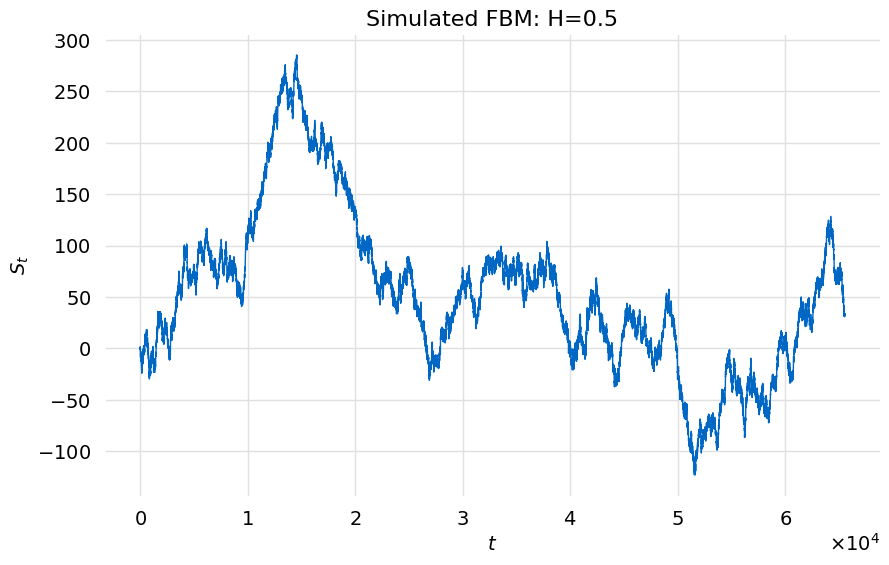

In [4]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

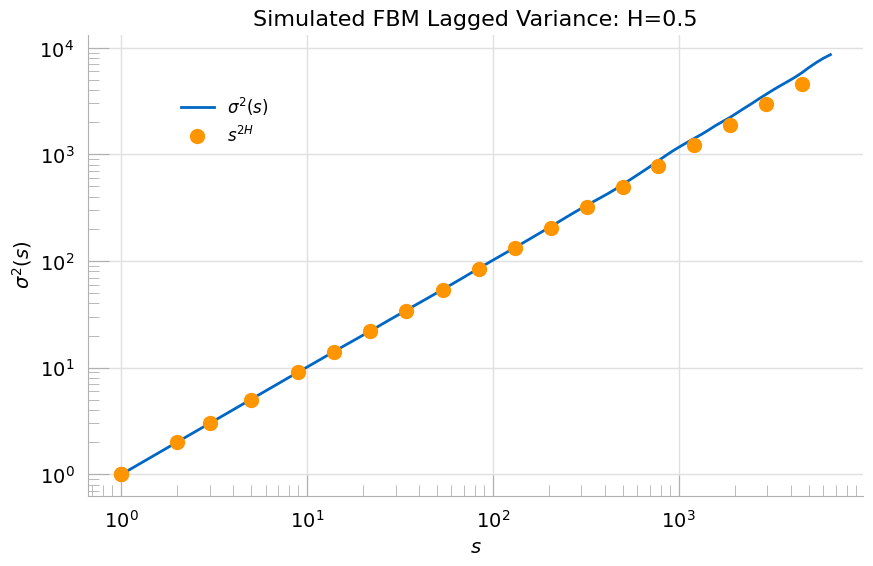

In [5]:
lag_var_plot(samples[0], H_vals[0], npts)

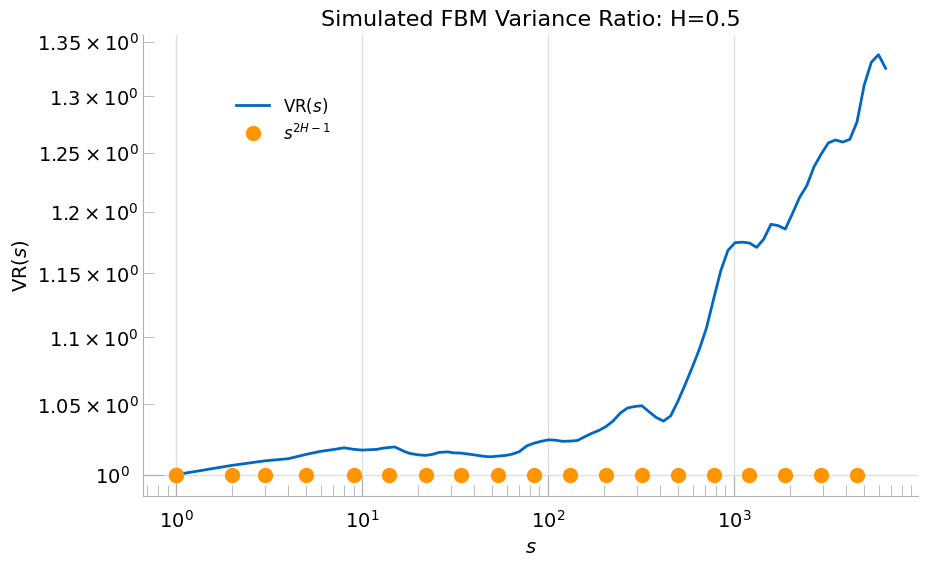

In [6]:
vr_plot(samples[0], H_vals[0], npts)

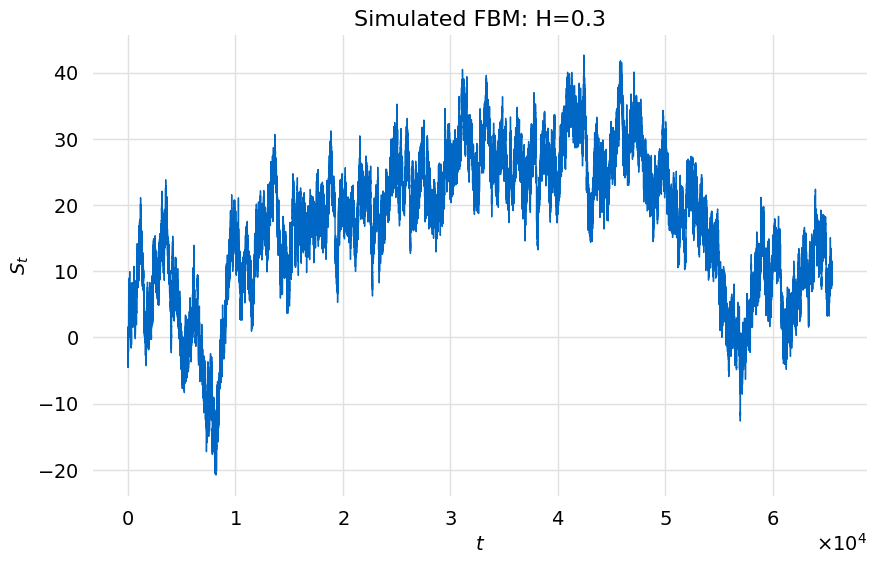

In [7]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

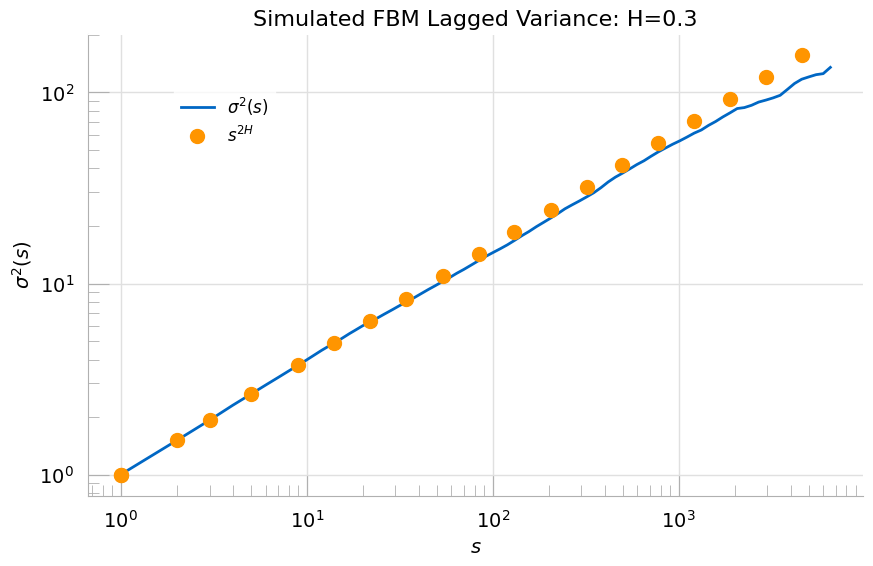

In [8]:
lag_var_plot(samples[1], H_vals[1], npts)

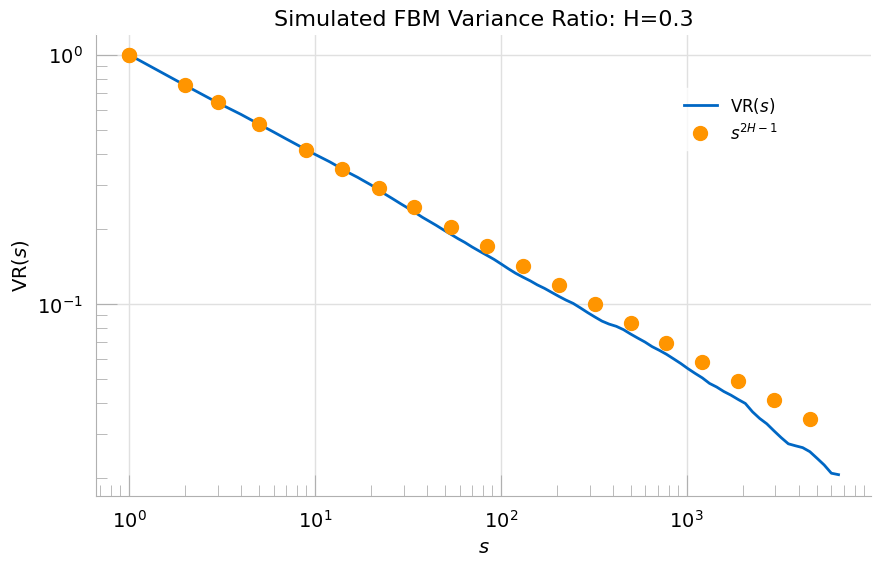

In [9]:
vr_plot(samples[1], H_vals[1], npts)

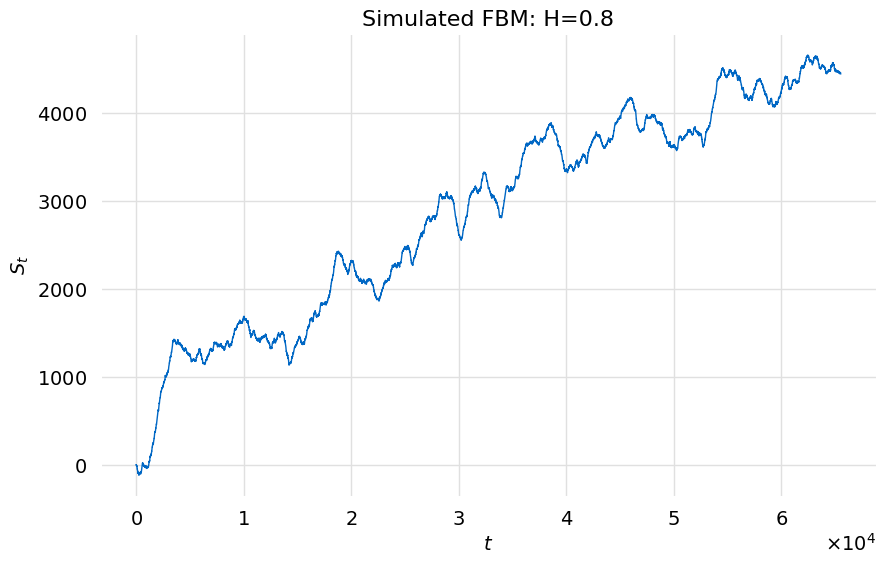

In [10]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

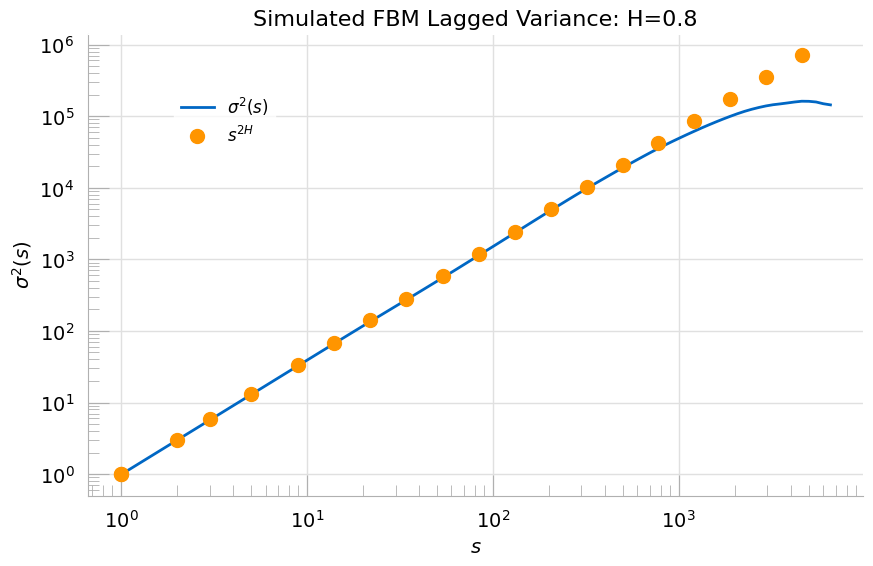

In [11]:
lag_var_plot(samples[2], H_vals[2], npts)

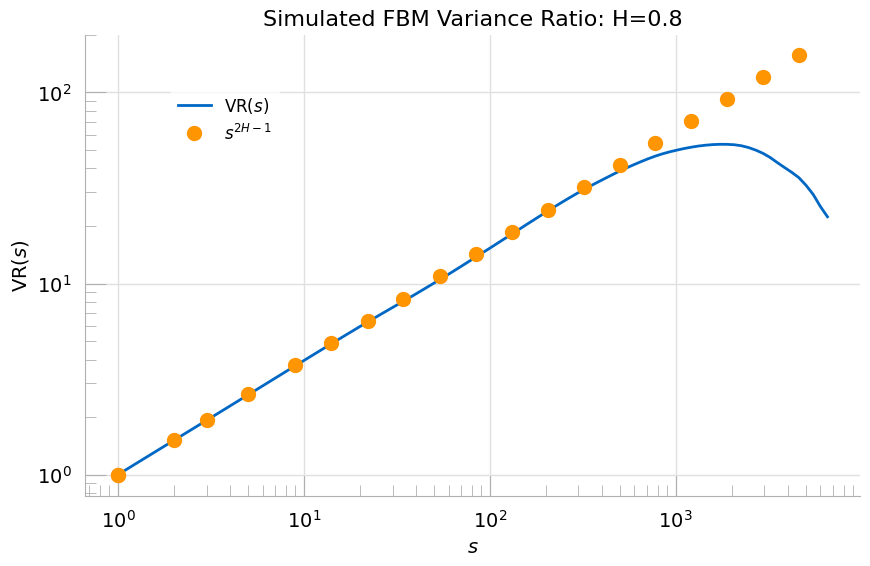

In [12]:
vr_plot(samples[2], H_vals[2], npts)

## Small Sample Size

In the previous verification section a rather large sample size was used to provide enough data to compute accurate averages. In general</br>
this is not practical. here more realistic sample sizes are used to see the impact on the analysis. 

In [13]:
npts = 2**9
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

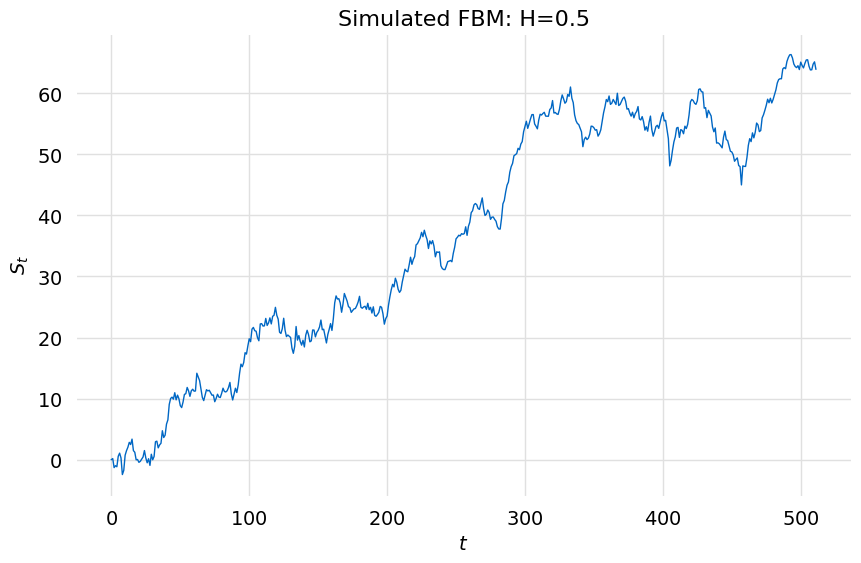

In [14]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

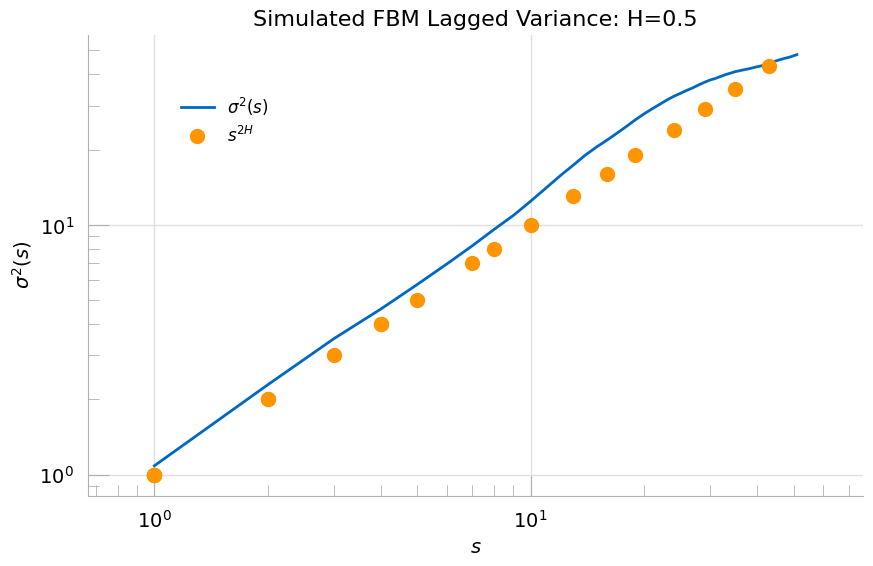

In [15]:
lag_var_plot(samples[0], H_vals[0], npts)

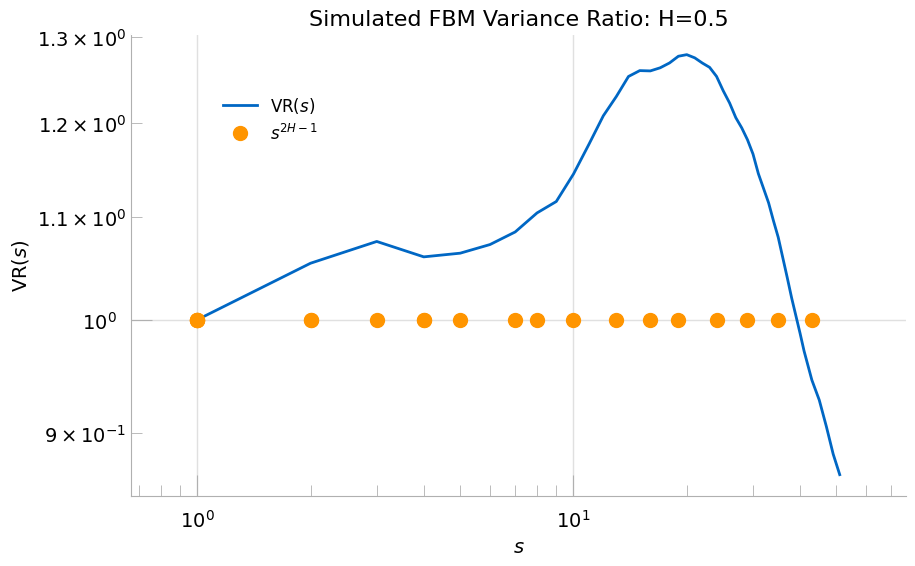

In [16]:
vr_plot(samples[0], H_vals[0], npts)

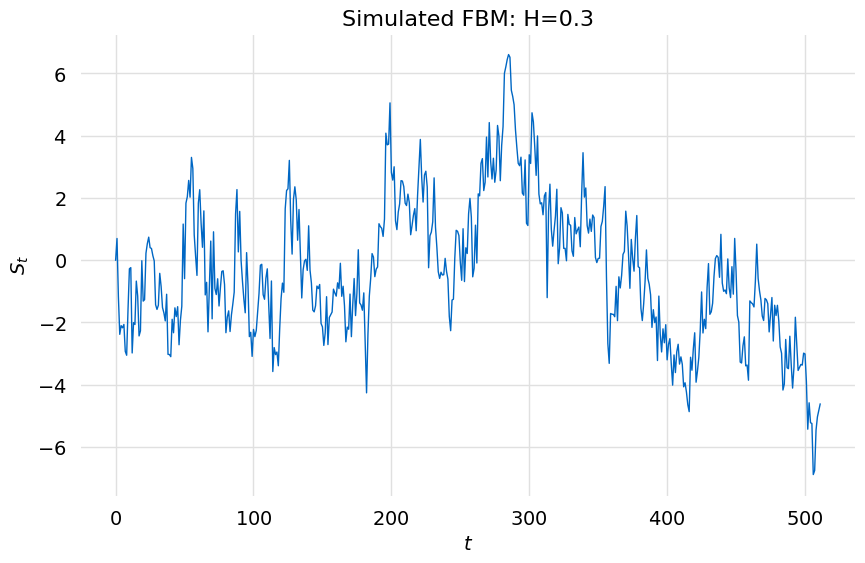

In [17]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

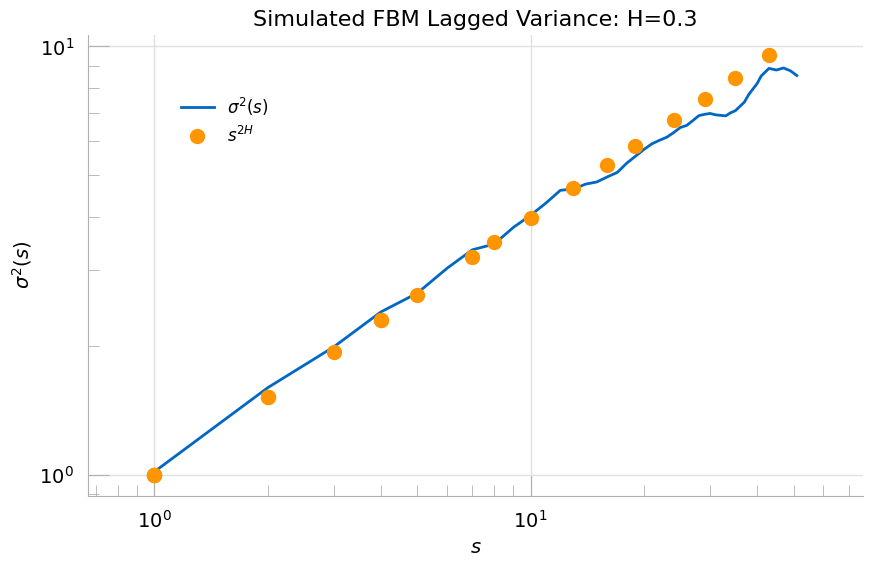

In [18]:
lag_var_plot(samples[1], H_vals[1], npts)

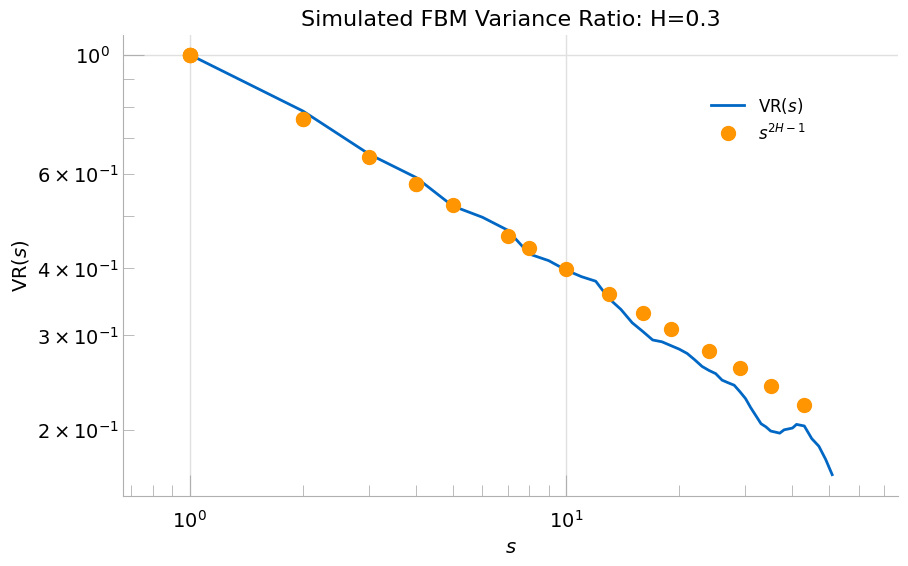

In [19]:
vr_plot(samples[1], H_vals[1], npts)

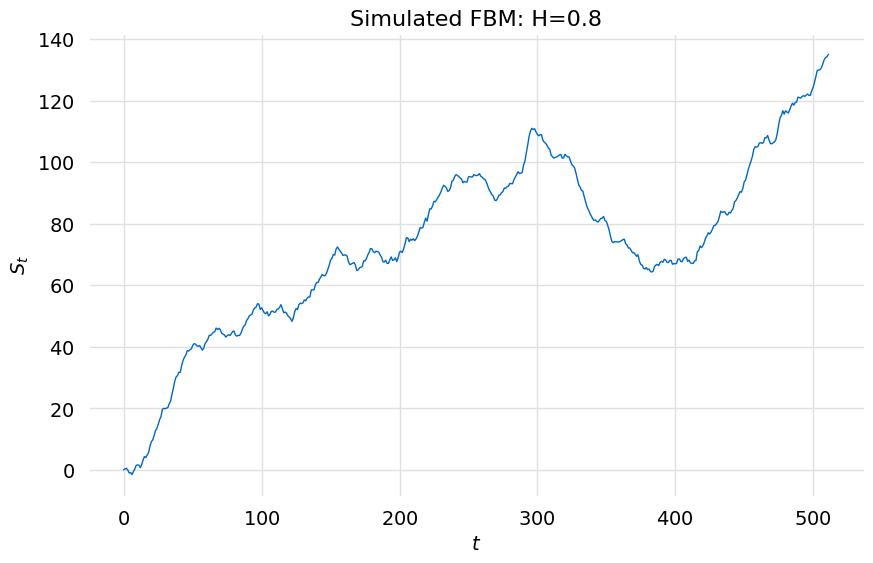

In [20]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

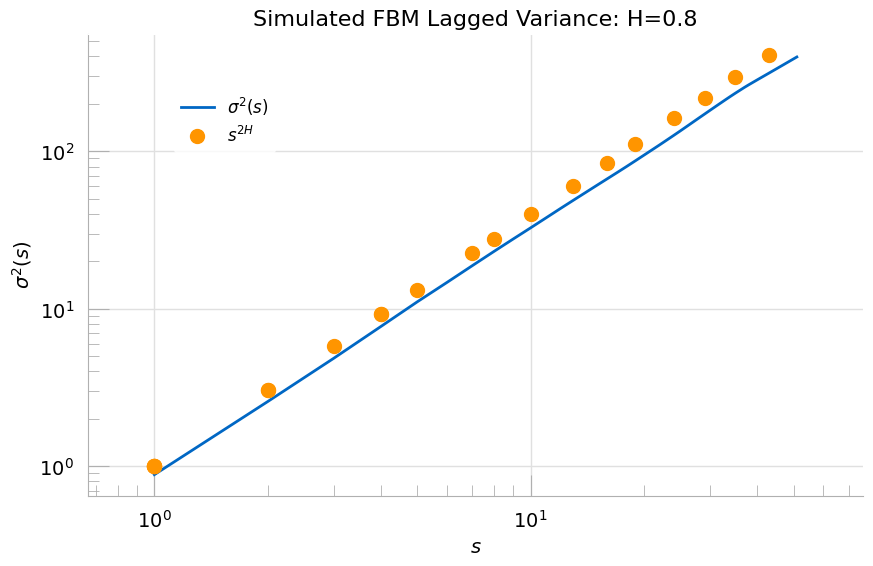

In [21]:
lag_var_plot(samples[2], H_vals[2], npts)

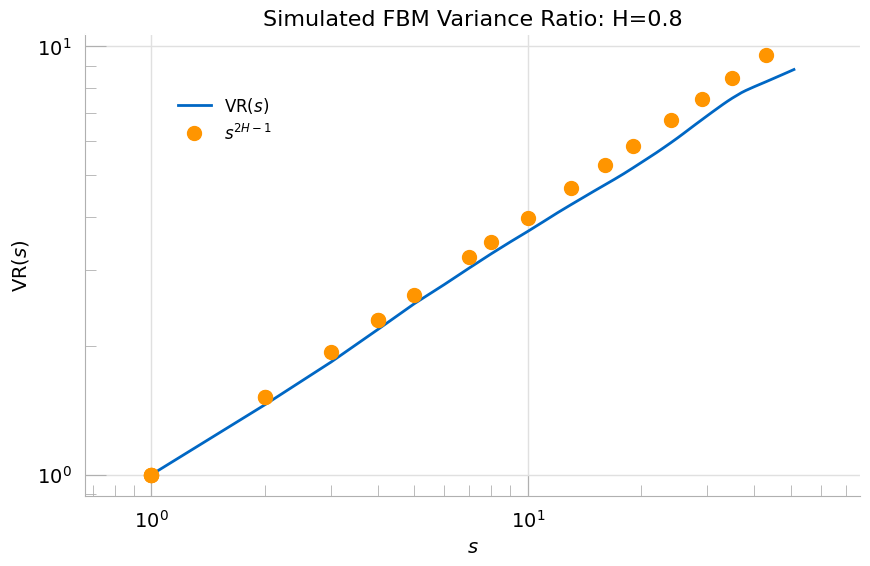

In [22]:
vr_plot(samples[2], H_vals[2], npts)

## Variance Ratio Test Comparison

In this section simulations that test the homoscedastic and heteroscedastic variance ratio test statistic are presented. It is seen that the results are not</br>
significantly different despite the greater cost of the heteroscedastic calculation. First large time series are</br>
analyzed followed by more realistic series lengths. A range of $H$ values is used.

In [23]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.5, 0.3, 0.7]
t, samples = create(H_vals, npts)

### H = 0.5 

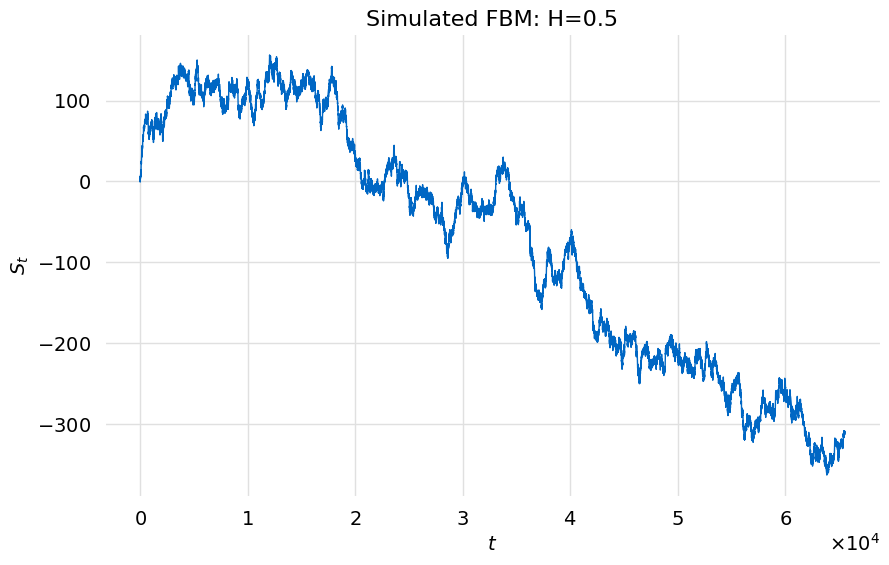

In [24]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [25]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.881 │    0.378 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.742 │    0.458 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.58  │    0.562 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.265 │    0.791 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [26]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 0.8807321494147585,
                "test_id": "07ccac76-256a-46ce-ac4f-6b319abb995b"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.3784628115358548,
                "test_id": "07ccac76-256a-46ce-ac4f-6b319abb995b"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "07ccac76-256a-46ce-ac4f-6b319abb995b"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "07ccac76-256a-46ce-ac4f-6b319abb995b"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536269514729,
      

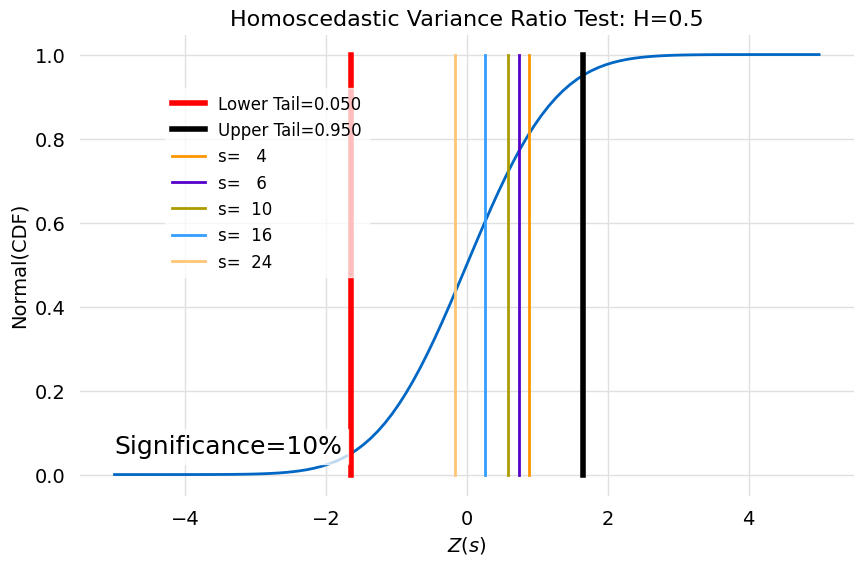

In [27]:
homo_test_stat_plot(result, H_vals[0])

In [28]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.885 │    0.376 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.745 │    0.456 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.581 │    0.561 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.265 │    0.791 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [29]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 0.884647727371637,
                "test_id": "bcce710e-9f8e-4fda-9724-cf1bf81c67c8"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.3763466566952236,
                "test_id": "bcce710e-9f8e-4fda-9724-cf1bf81c67c8"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "bcce710e-9f8e-4fda-9724-cf1bf81c67c8"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "bcce710e-9f8e-4fda-9724-cf1bf81c67c8"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536269514729,
       

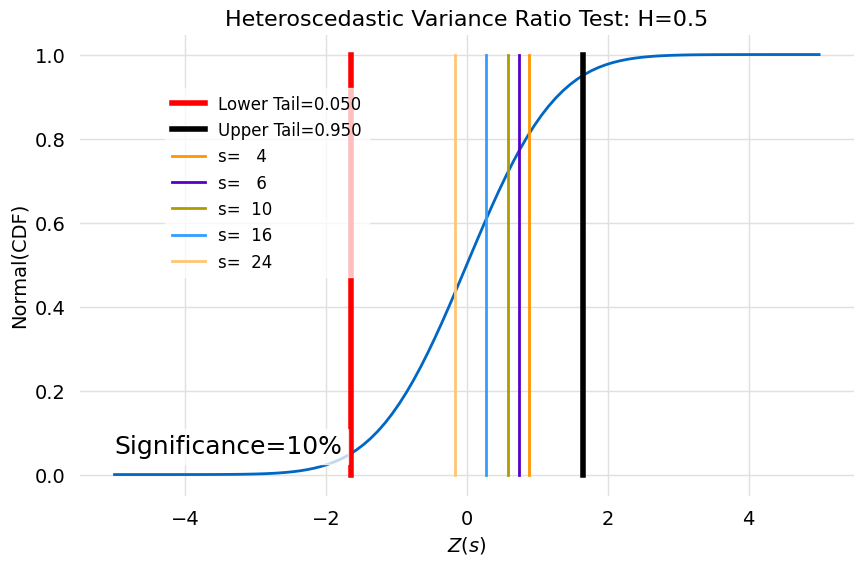

In [30]:
hetero_test_stat_plot(result, H_vals[0])

### H = 0.3

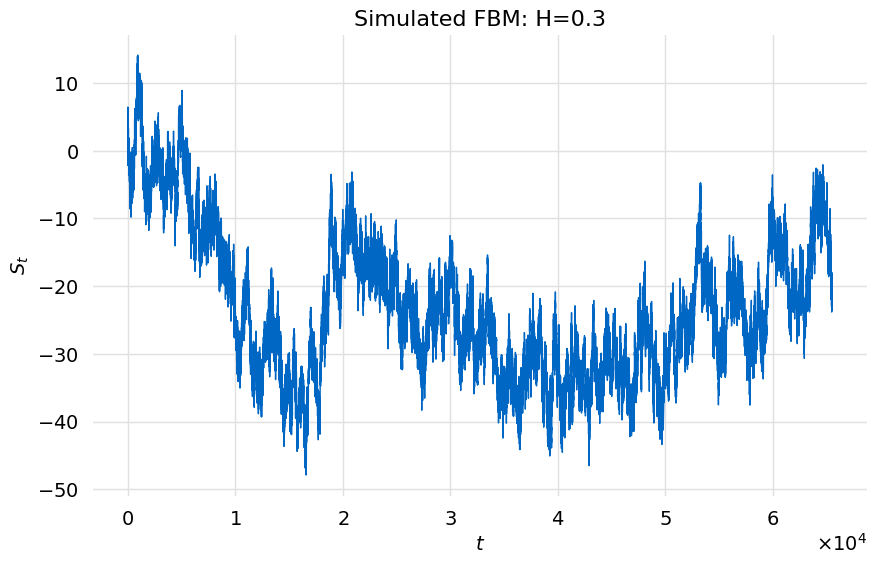

In [31]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [32]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -58.875 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -53.795 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -46.1   │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -39.147 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

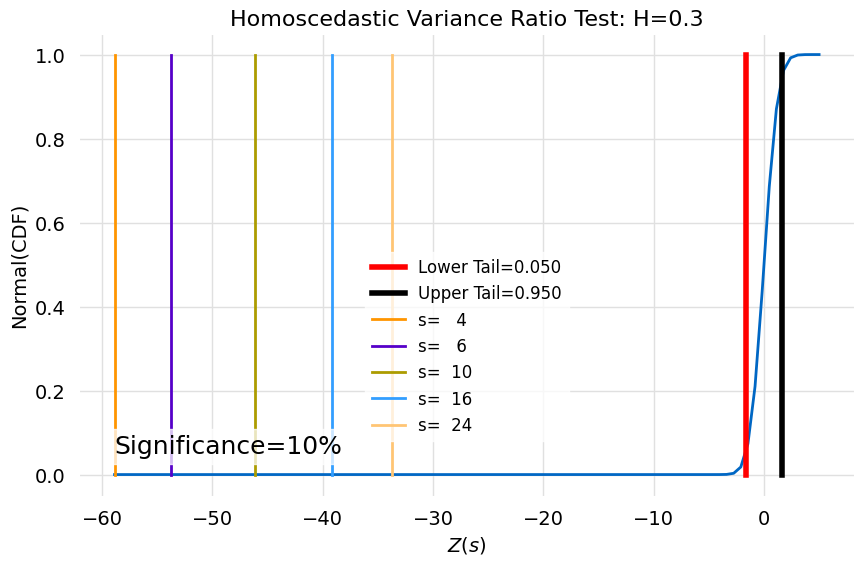

In [33]:
homo_test_stat_plot(result, H_vals[1])

In [34]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -56.317 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -52.031 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -45.095 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.598 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

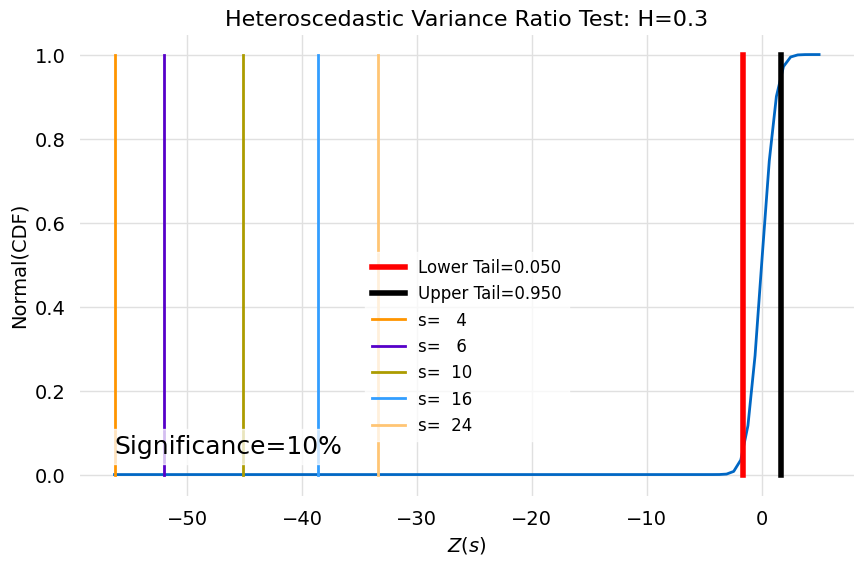

In [35]:
hetero_test_stat_plot(result, H_vals[1])

### H=0.7

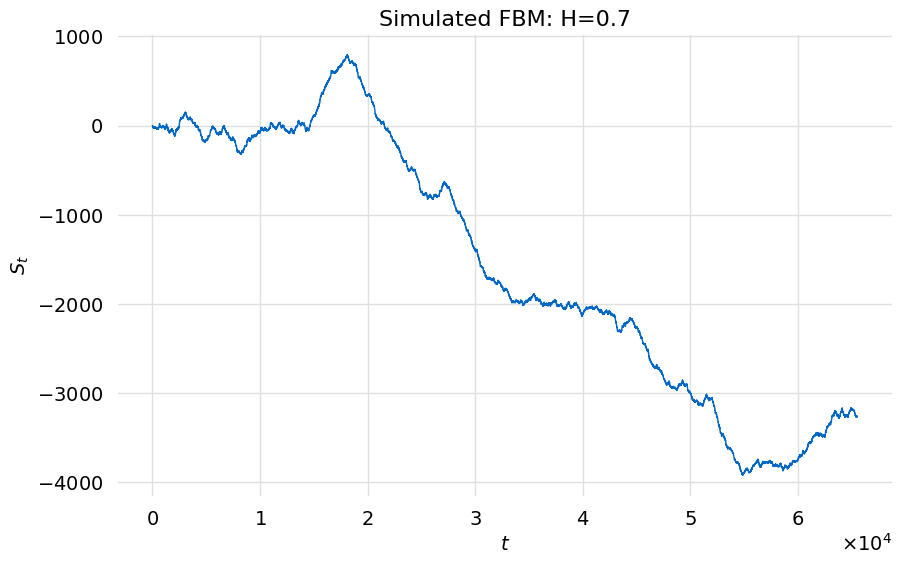

In [36]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [37]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ 101.859 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 108.15  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 113.337 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 116.704 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

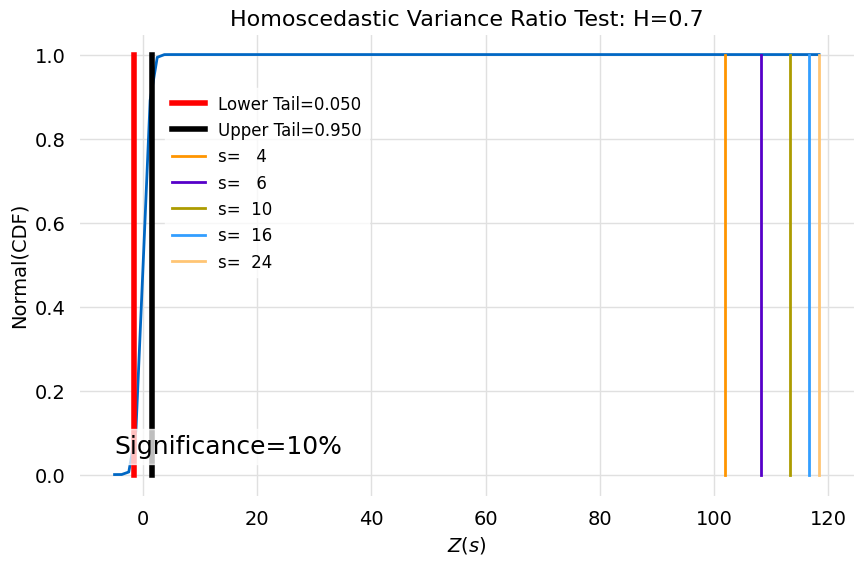

In [38]:
homo_test_stat_plot(result, H_vals[2])

In [39]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  95.122 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 102.309 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 108.8   │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 113.239 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

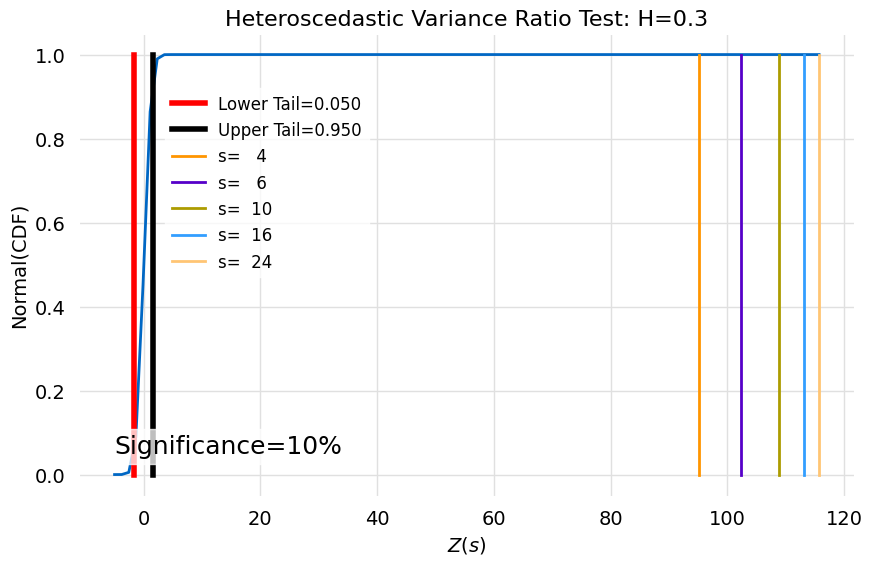

In [40]:
hetero_test_stat_plot(result, H_vals[1])

### Values Near H=0.5

The performance of the homoscedastic and heteroscedastic for values near $H=0.5$ is evaluated.

In [41]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.475, 0.49, 0.51, 0.525]
t, samples = create(H_vals, npts)

#### H=0.51

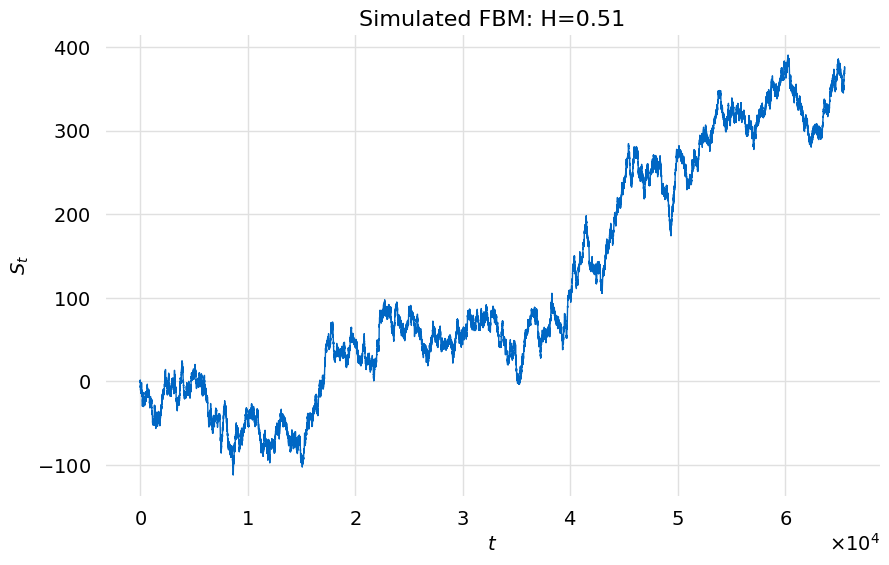

In [42]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [43]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  4.375 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  4.225 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.31  │    0.021 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.264 │    0.792 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

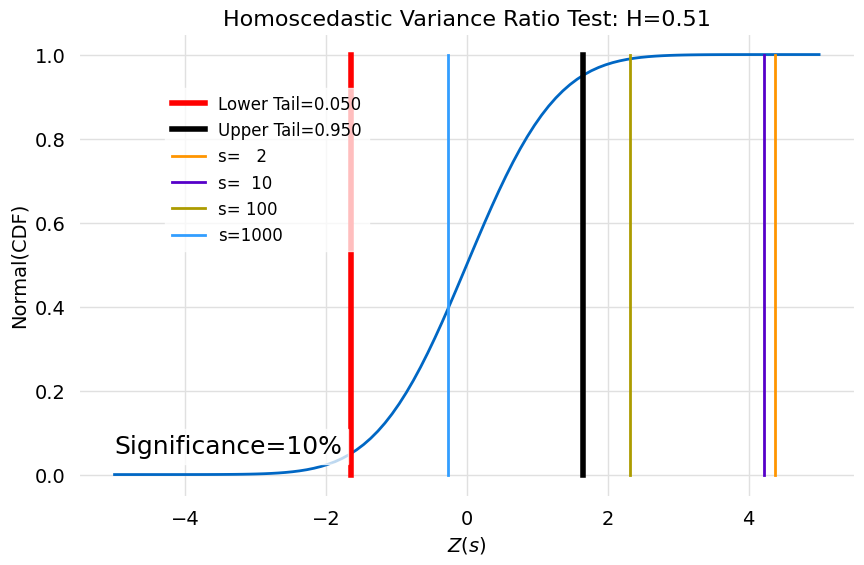

In [44]:
homo_test_stat_plot(result, H_vals[2])

In [45]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  4.367 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  4.212 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  2.308 │    0.021 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.265 │    0.791 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

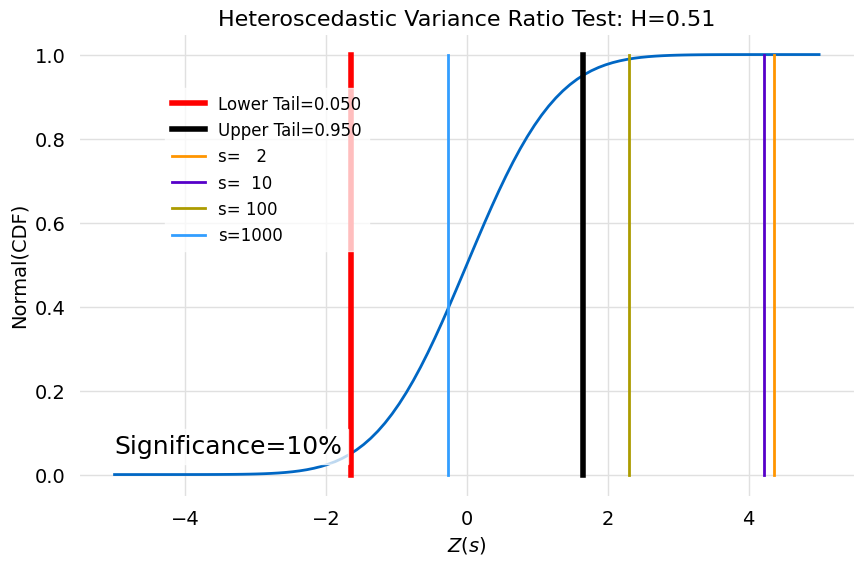

In [46]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.49

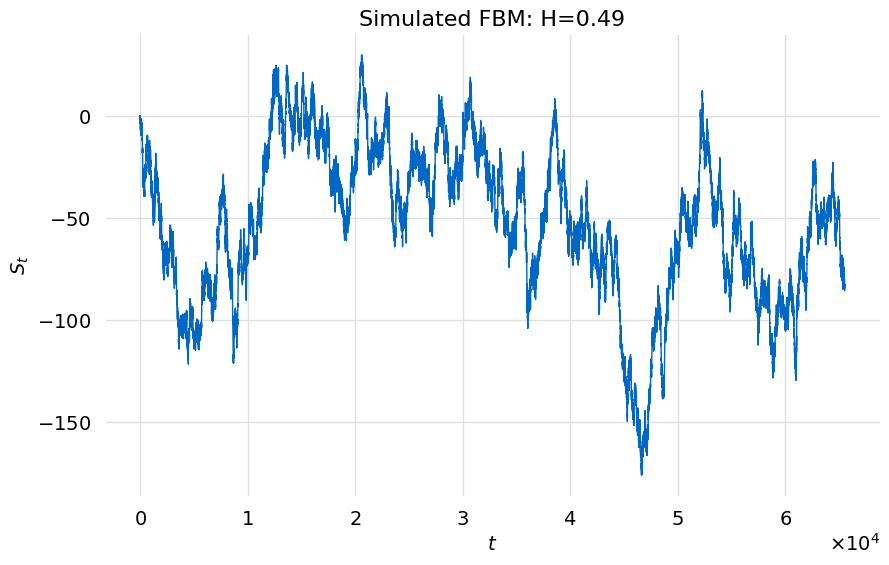

In [47]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [48]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.116 │    0.002 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -4.3   │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.369 │    0.171 │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.51  │    0.131 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

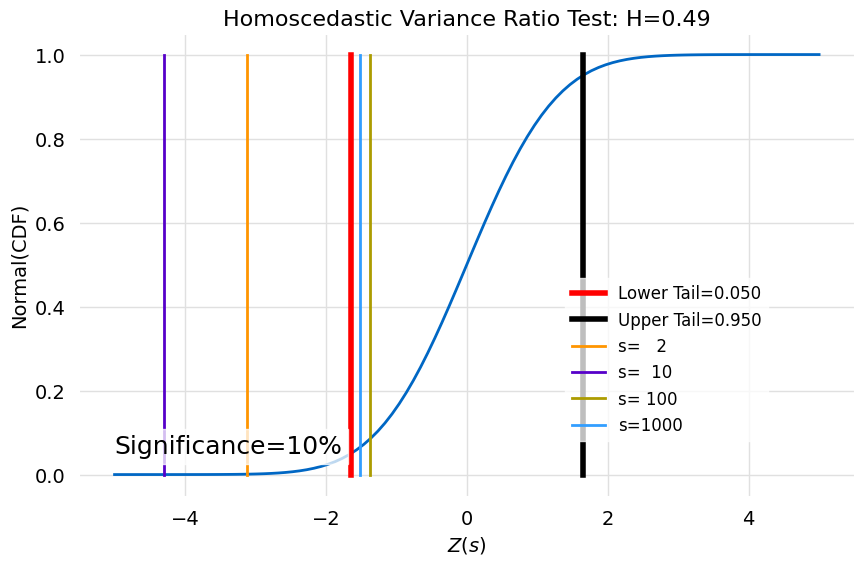

In [49]:
homo_test_stat_plot(result, H_vals[1])

In [50]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.103 │    0.002 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -4.297 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.369 │    0.171 │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.513 │    0.13  │ Passed   │
╘══════╧════════╧══════════╧══════════╛

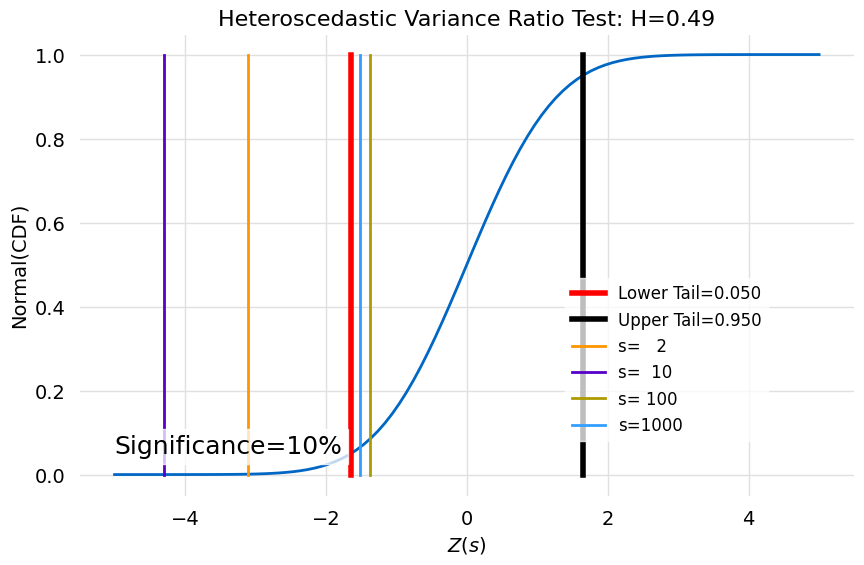

In [51]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.475

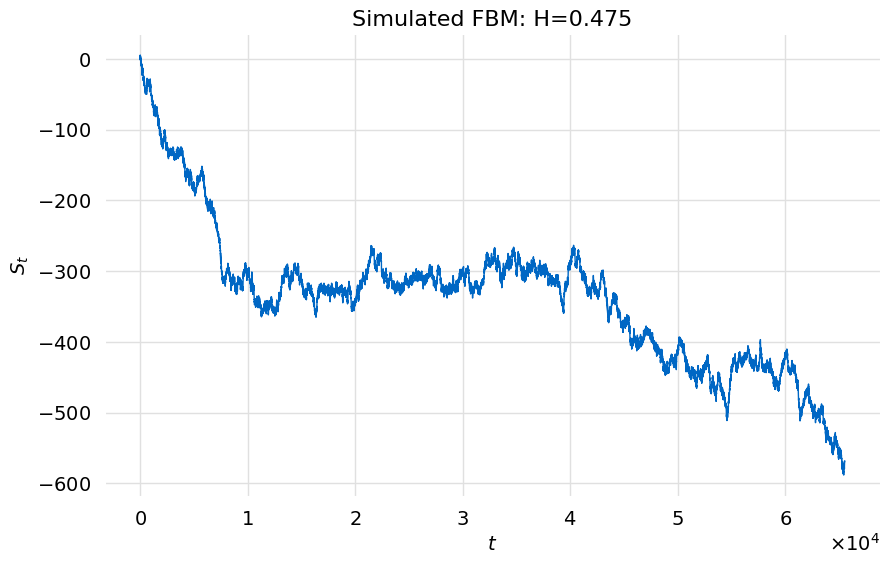

In [52]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [53]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -6.459 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -5.814 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -3.618 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.91  │    0.056 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

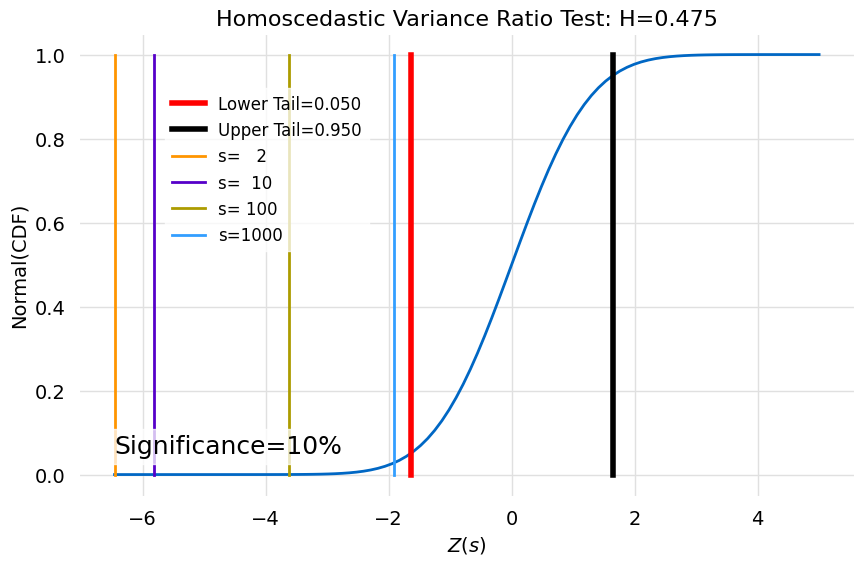

In [54]:
homo_test_stat_plot(result, H_vals[0])

In [55]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -6.424 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -5.816 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -3.619 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.913 │    0.056 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

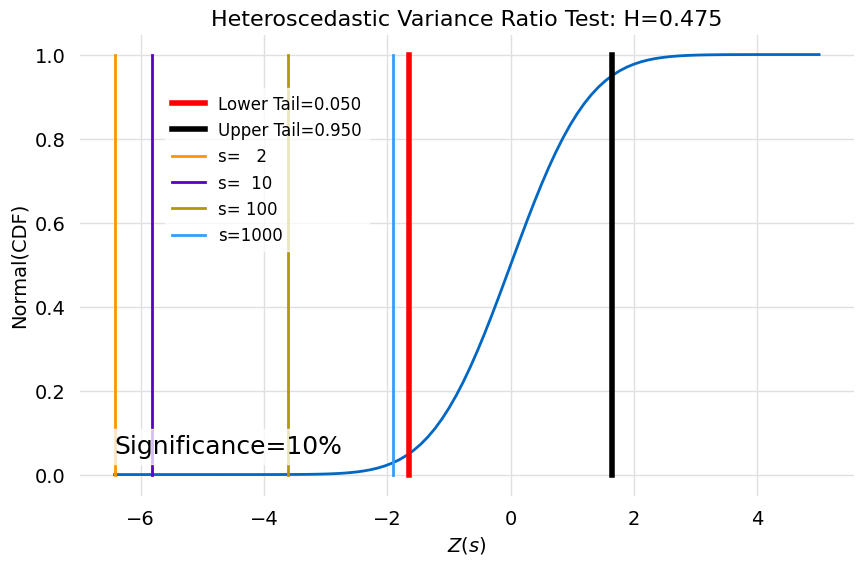

In [56]:
hetero_test_stat_plot(result, H_vals[0])

### Small Sample Size

In [57]:
npts = 2**9
s_vals = [4, 10, 25, 50, 100]
H_vals = [0.5, 0.7, 0.3]
t, samples = create(H_vals, npts)

#### H=0.5

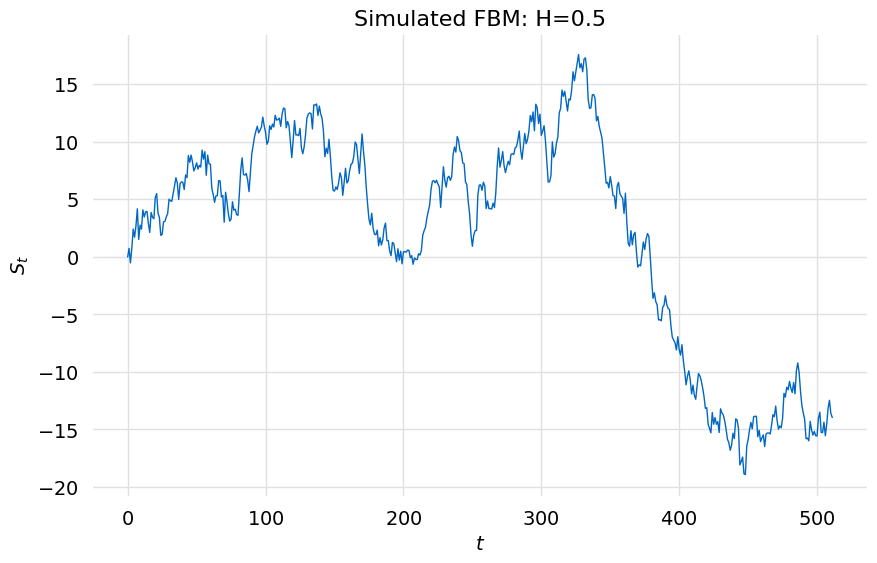

In [58]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [59]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.356 │    0.722 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.339 │    0.735 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.107 │    0.915 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.658 │    0.51  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  1

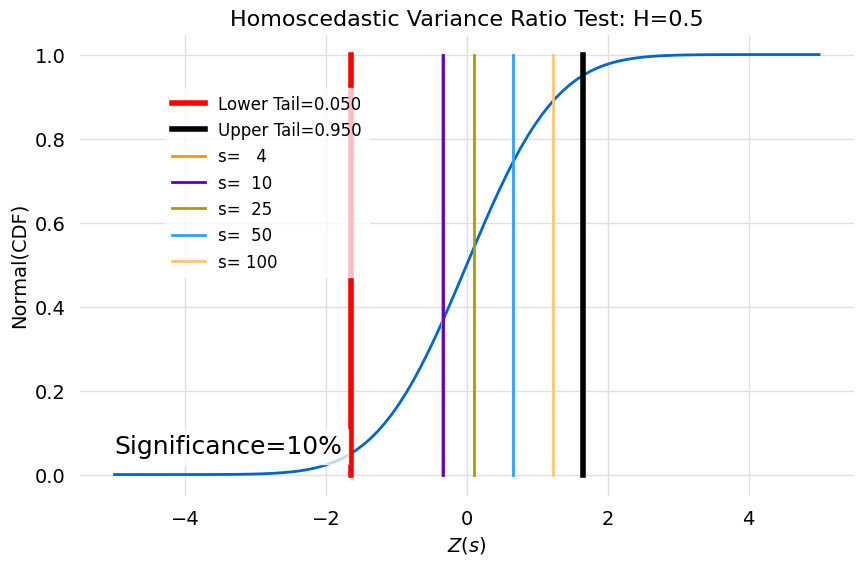

In [60]:
homo_test_stat_plot(result, H_vals[0])

In [61]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.352 │    0.725 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.339 │    0.735 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.108 │    0.914 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.672 │    0.501 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  1

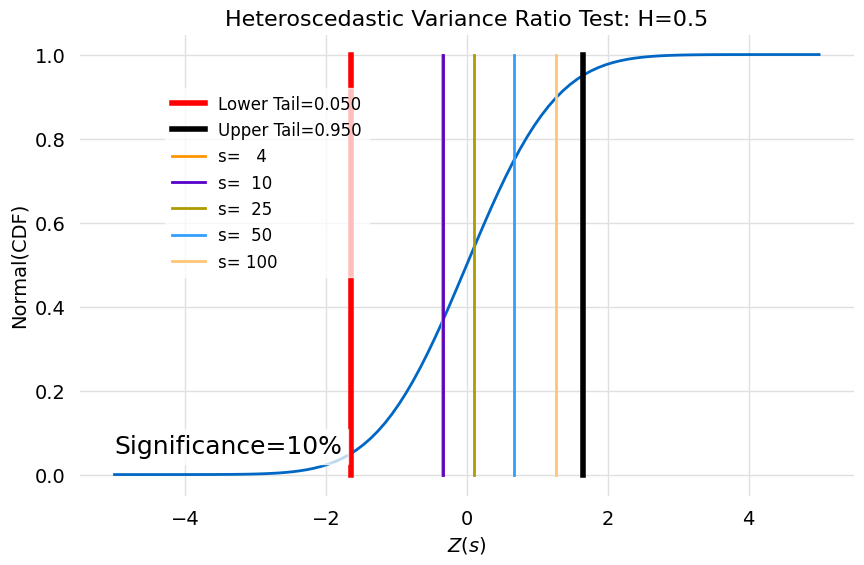

In [62]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.7

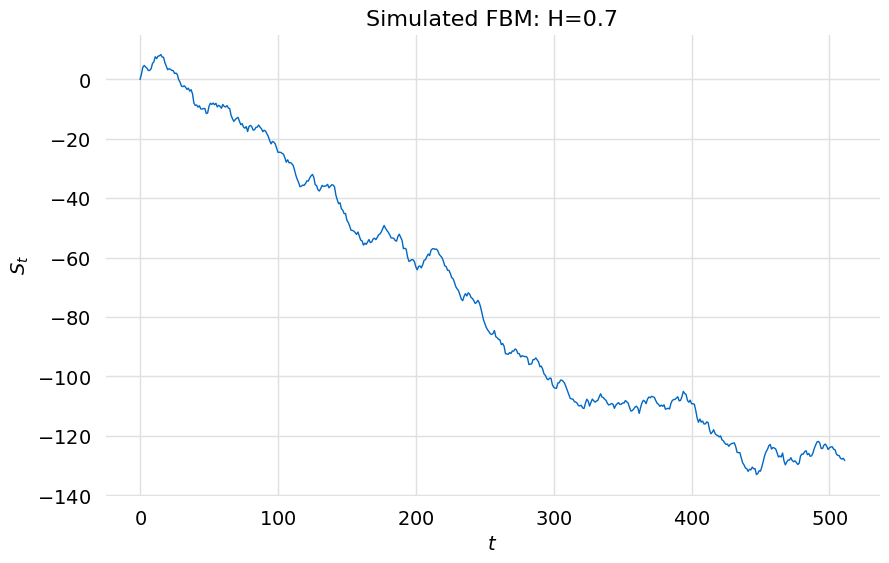

In [63]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [64]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.635 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  5.472 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  3.212 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  2.837 │    0.005 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  2

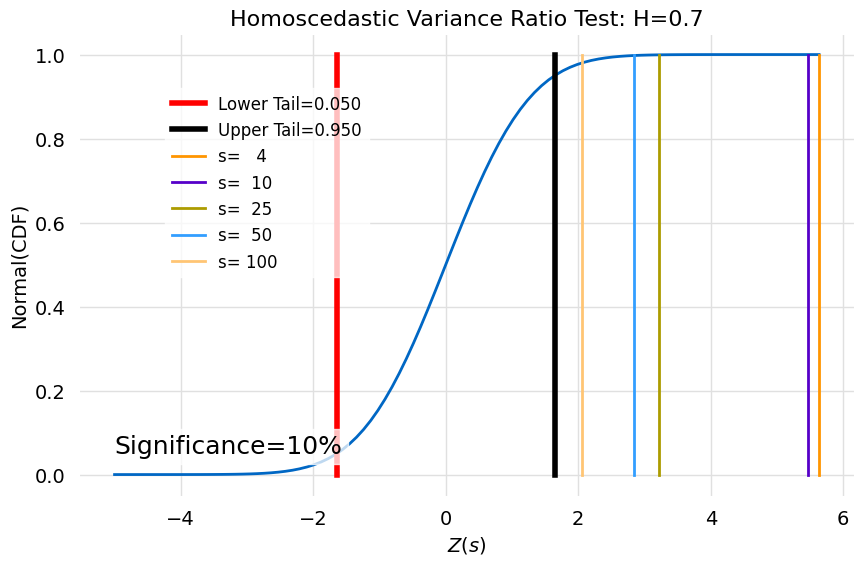

In [65]:
homo_test_stat_plot(result, H_vals[1])

In [66]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.461 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  5.505 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  3.267 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  2.908 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  2

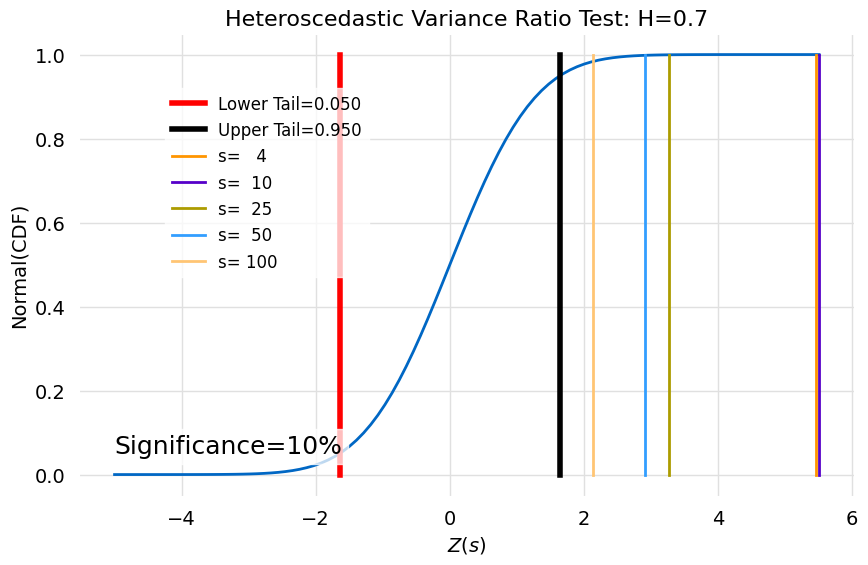

In [67]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.3

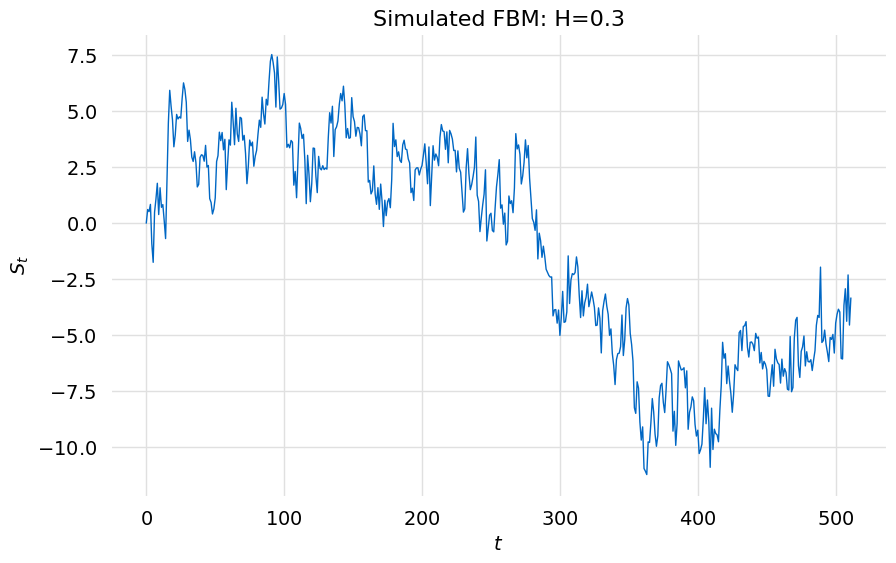

In [68]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [69]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.493 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.992 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.885 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.283 │    0.022 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

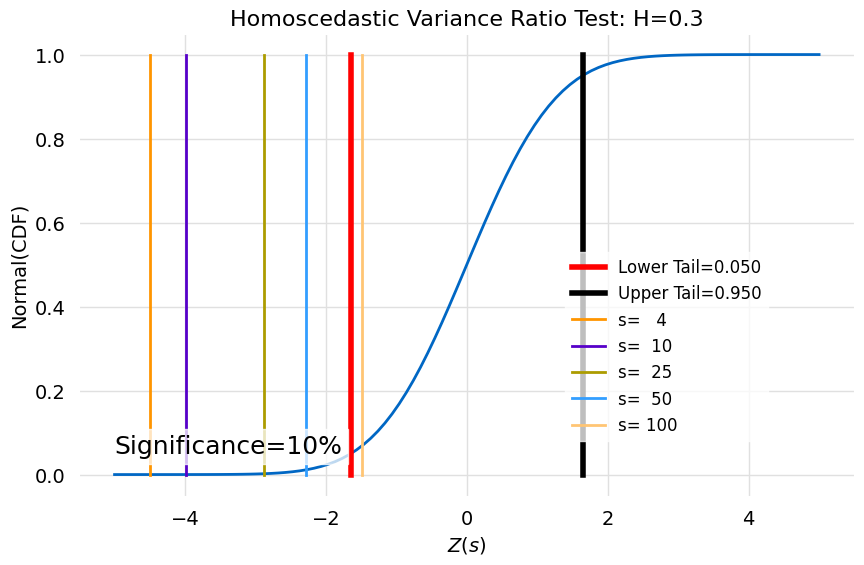

In [70]:
homo_test_stat_plot(result, H_vals[2])

In [71]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.204 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.963 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.949 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.368 │    0.018 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

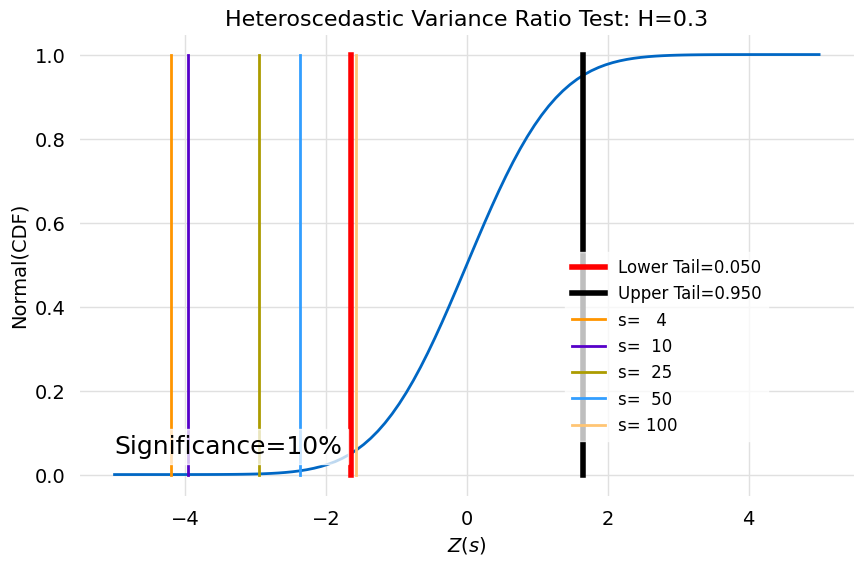

In [72]:
hetero_test_stat_plot(result, H_vals[2])

### Values Near H=0.5

In [73]:
npts = 2**9
s_vals = [2, 4, 10, 25, 50]
H_vals = [0.49, 0.45, 0.4, 0.51, 0.55]
t, samples = create(H_vals, npts)

#### H=0.49

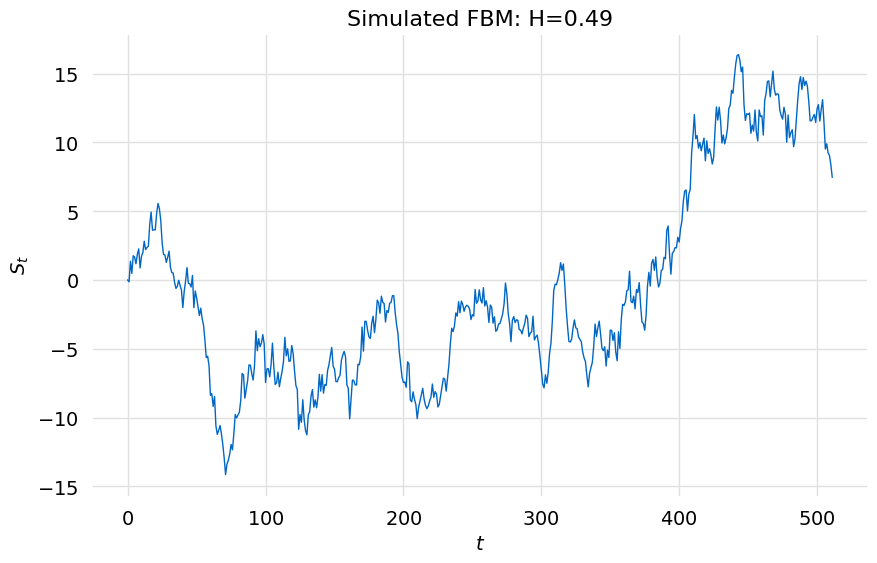

In [74]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [75]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.087 │    0.277 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.331 │    0.741 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.175 │    0.861 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.506 │    0.613 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

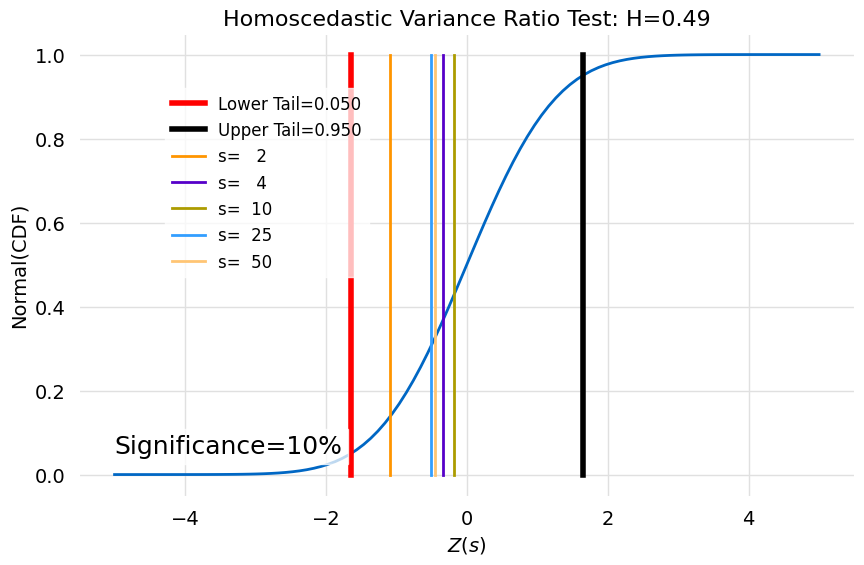

In [76]:
homo_test_stat_plot(result, H_vals[0])

In [77]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.049 │    0.294 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.324 │    0.746 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.176 │    0.86  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.509 │    0.611 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

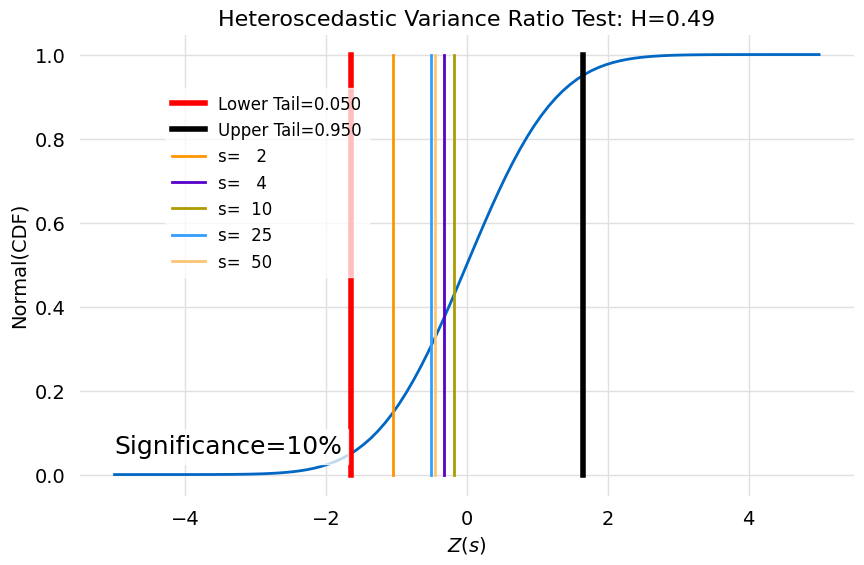

In [78]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.45

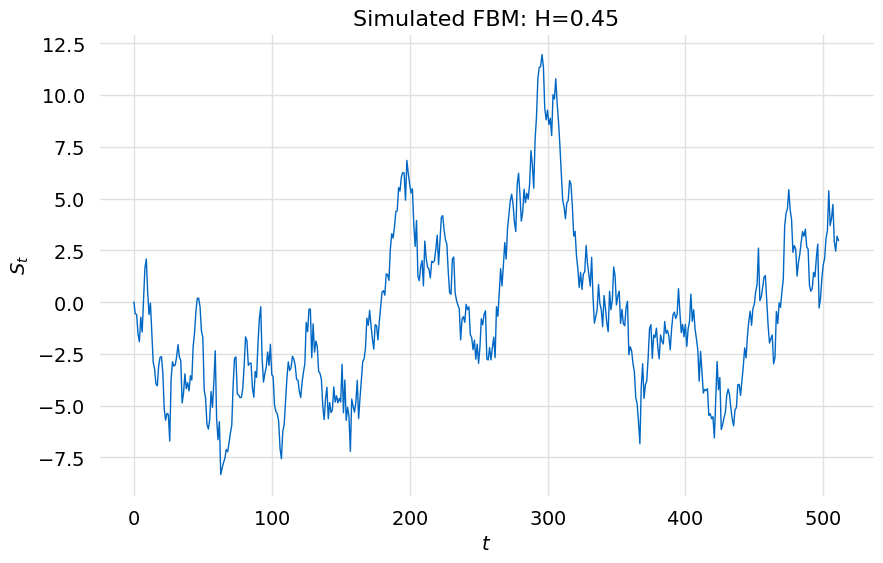

In [79]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [80]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.06  │    0.039 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.308 │    0.191 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.592 │    0.111 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.19  │    0.234 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

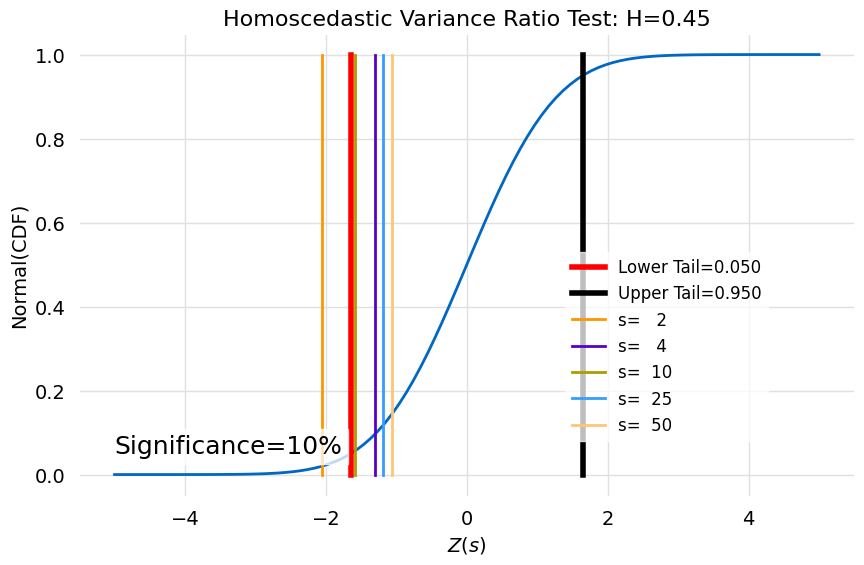

In [81]:
homo_test_stat_plot(result, H_vals[1])

In [82]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.082 │    0.037 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.327 │    0.185 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.622 │    0.105 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.217 │    0.224 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

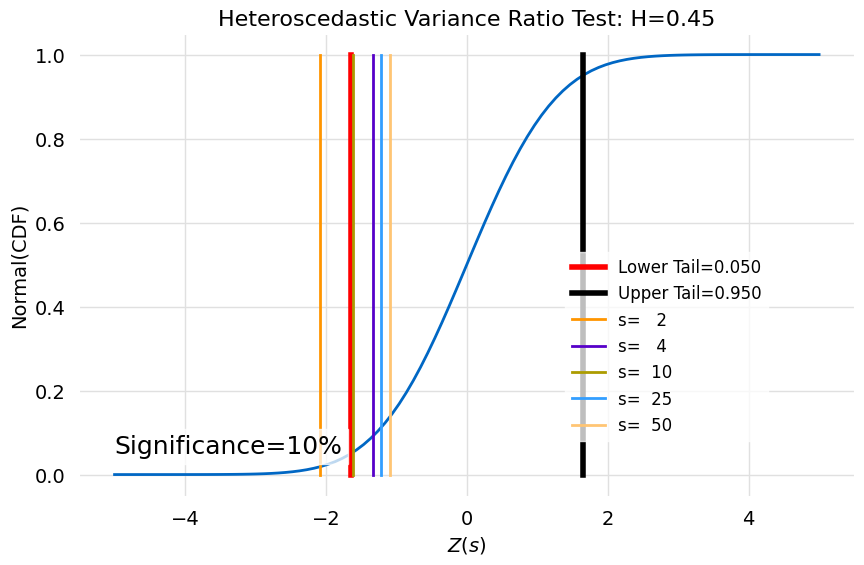

In [83]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.4

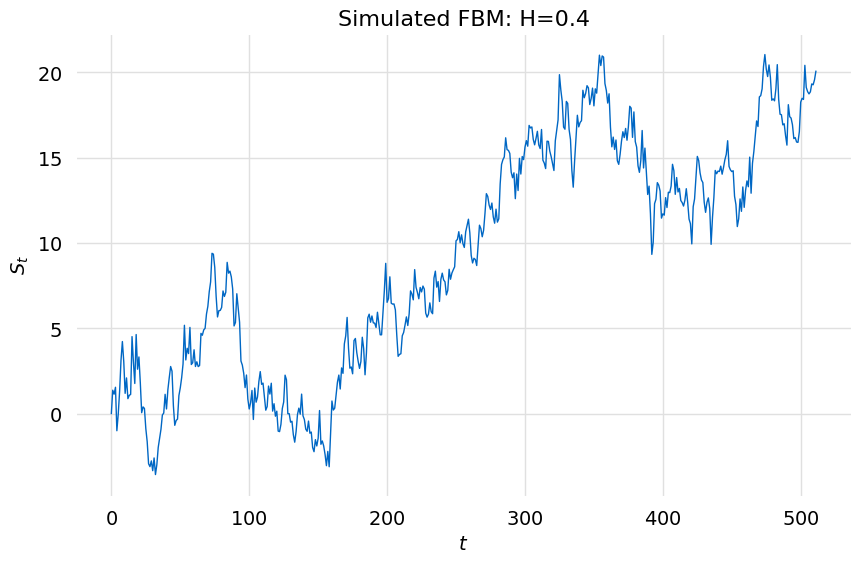

In [84]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [85]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.952 │    0.051 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.748 │    0.081 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.11  │    0.035 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.994 │    0.046 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

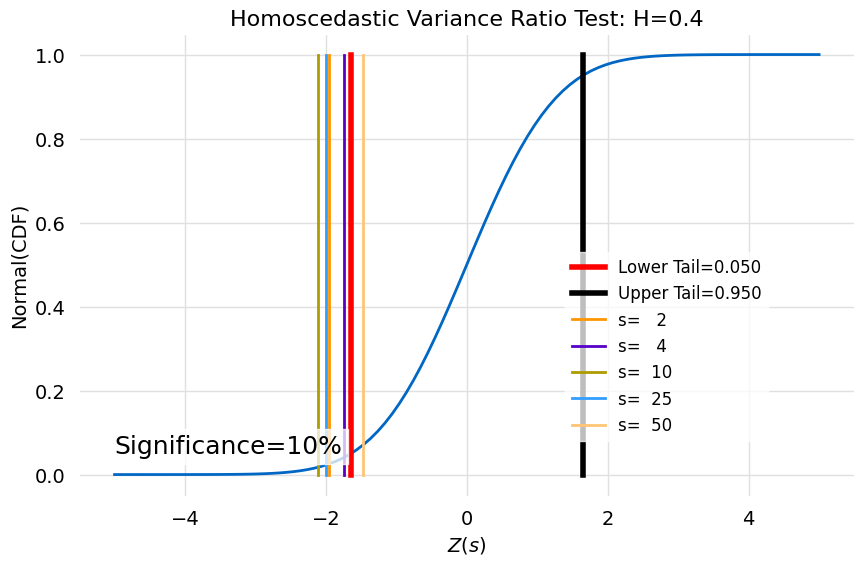

In [86]:
homo_test_stat_plot(result, H_vals[2])

In [87]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.837 │    0.066 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.668 │    0.095 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.013 │    0.044 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.942 │    0.052 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

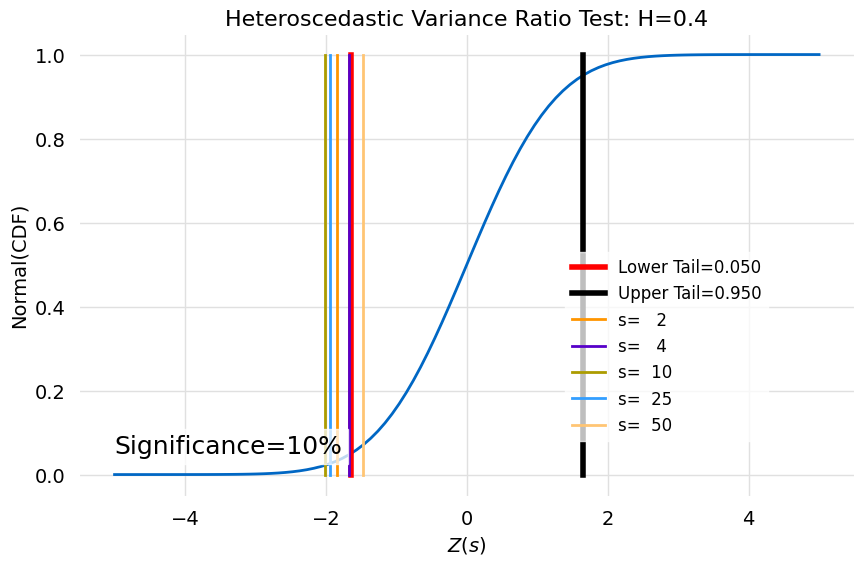

In [88]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.51

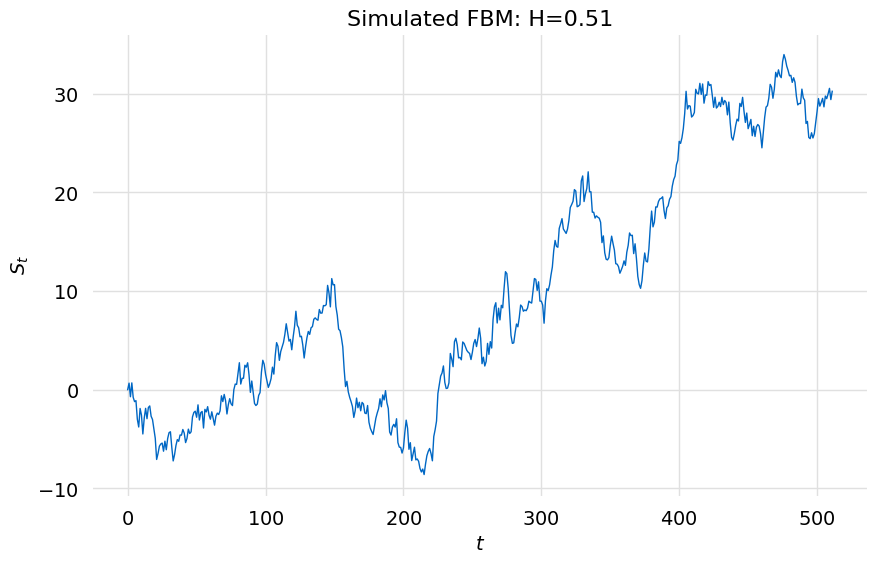

In [89]:
title = f"Simulated FBM: H={H_vals[3]}"
curve(samples[3], t[3], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [90]:
result, result_model = fbm.compute_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.034 │    0.973 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.417 │    0.677 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.006 │    0.995 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.488 │    0.625 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

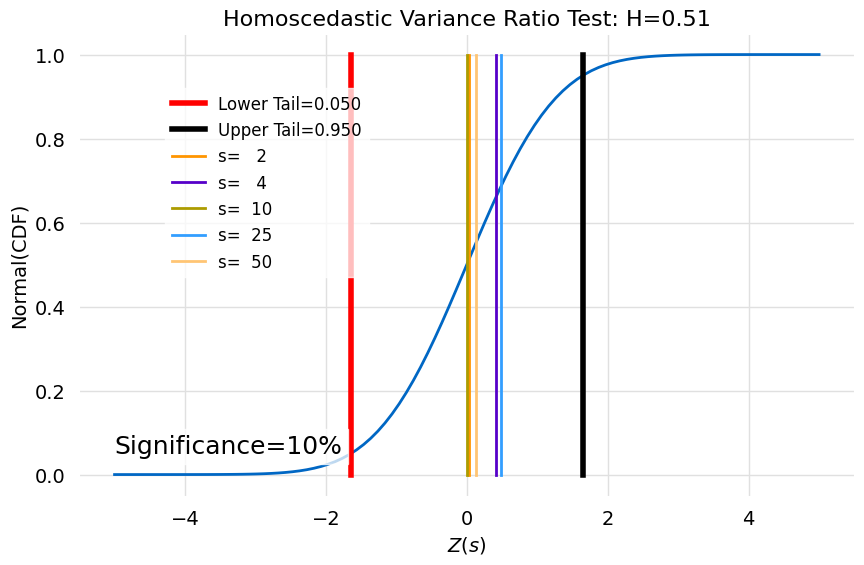

In [91]:
homo_test_stat_plot(result, H_vals[3])

In [92]:
result, result_model = fbm.compute_hetero_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.034 │    0.973 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.418 │    0.676 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.006 │    0.995 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.489 │    0.625 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

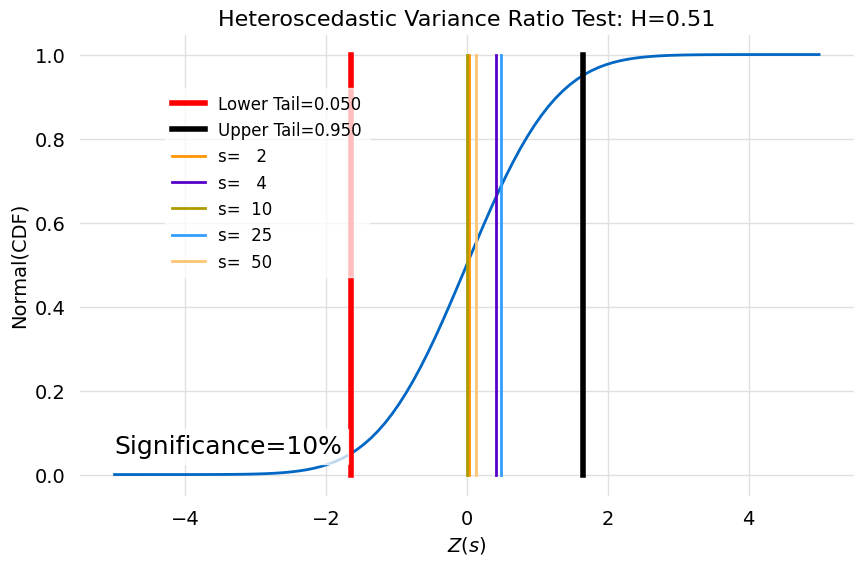

In [93]:
hetero_test_stat_plot(result, H_vals[3])

#### H=0.55

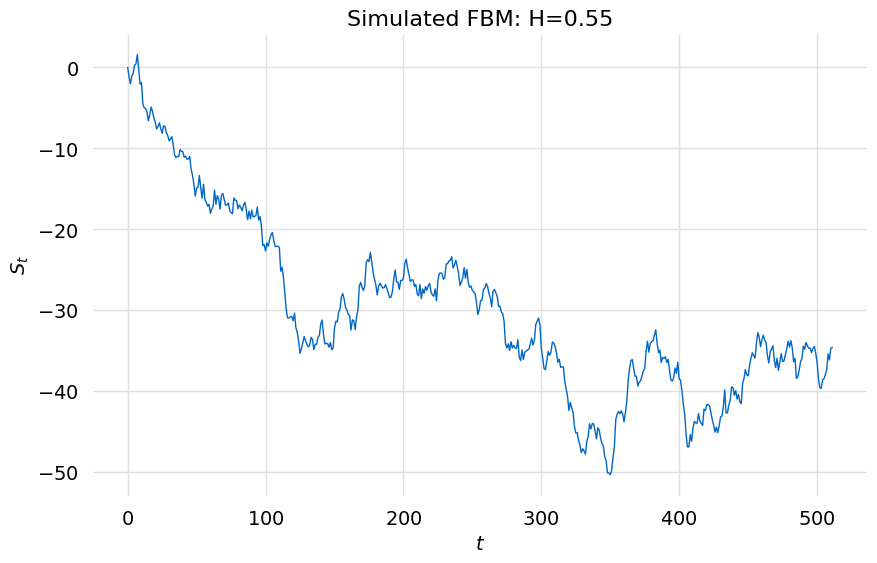

In [94]:
title = f"Simulated FBM: H={H_vals[4]}"
curve(samples[4], t[4], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [95]:
result, result_model = fbm.compute_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  1.847 │    0.065 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.888 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.152 │    0.249 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  1.433 │    0.152 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

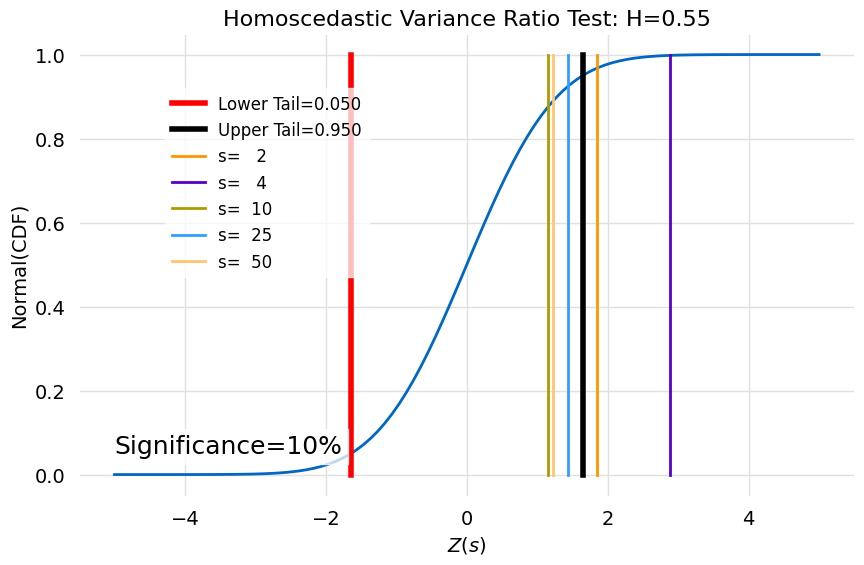

In [96]:
homo_test_stat_plot(result, H_vals[4])

In [97]:
result, result_model = fbm.compute_hetero_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  1.822 │    0.068 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.874 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.169 │    0.242 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  1.465 │    0.143 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

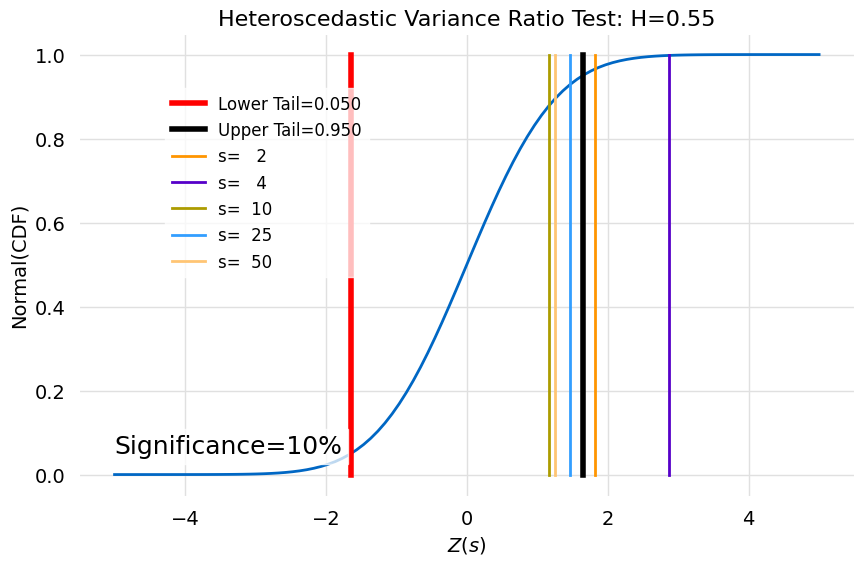

In [98]:
hetero_test_stat_plot(result, H_vals[4])

## Variance Ratio Test

Here the performance of the variance ratio test is evaluated. In the previous analysis the performance of the homoscedastic test was not significantly different</br>
than the heteroscedastic test. Since the homoscedastic test is much faster it is used. The values of the variance ratio test statistic for $0 < H < \frac{1}{2}$, $H=\frac{1}{2}$</br>
and $\frac{1}{2} < H < 1$ respectively satisfy $Z(s) < 0$, $Z(s) = 0$ and $Z(s) > 0$. This follows from the variance ratio, $\text{VR}(s)$ satisfying $0 < \text{VR}(s) < 1$, $\text{VR}(s)=1$ and $\text{VR}(s) > 1$</br>
in that same regions. Plots of $Z(s)$ for these regions are shown below. It is seen for $0 < H < \frac{1}{2}$ that $Z(s)$ is an increasing function of $s$ and for $\frac{1}{2} < H < 1$</br>
$Z(s)$ has a more complex behavior but is increasing for smaller values of $s$. It follows that eventually for some value of $s$ the test will likely fail. This makes interpreting the tests</br> 
results somewhat difficult. In the previous analysis where $\text{VR}(s)$ was compared to $\sigma s^{2H-1}$ it was seen that for a series with $2^9$ points the the two values agreed well for</br>
up to $s=2^8$. This motivates evaluating $Z(s)$ in regions where it is always increasing using a sequence of values of $s$ satisfying $s \le 25$. For this range the agreement between $\text{VR}(s)$</br>
and $\sigma s^{2H-1}$ was best. $Z(s)$ is evaluated for each $s$ and the result is pass if at least one test passes and failed otherwise.

### $H \le \frac{1}{2}$

In [99]:
npts = 2**9
s_min=2.0
s_max=npts/2
s_npts=int(s_max - s_min + 1)

In [100]:
H_vals = [0.1, 0.2, 0.3, 0.4, 0.5]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

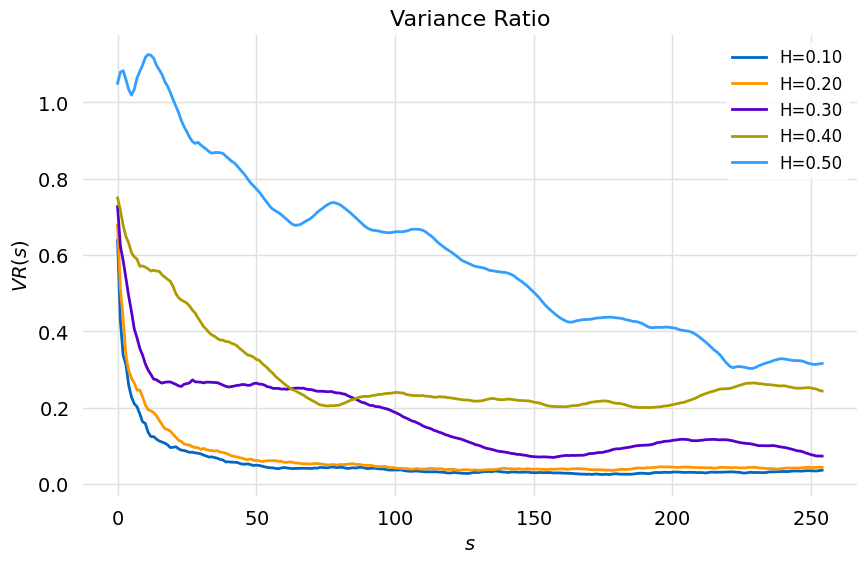

In [101]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H \ge \frac{1}{2}$

In [102]:
H_vals = [0.5, 0.6, 0.7, 0.8, 0.89]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

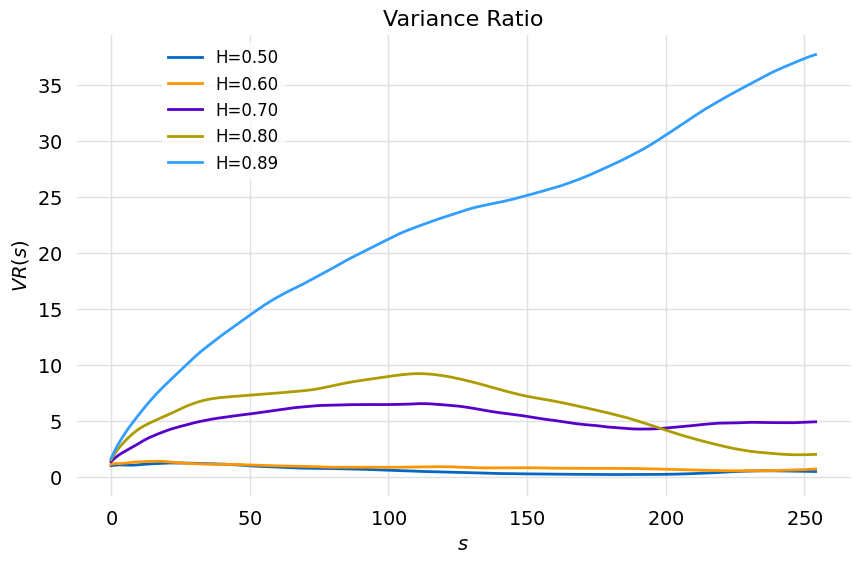

In [103]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H = 0.5$

Here a two tailed test for brownian motion is performed. This test is successful if the result is **PASSED**

In [104]:
H=0.5
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.047 │    0.295 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.602 │    0.547 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.145 │    0.885 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.274 │    0.784 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0

In [105]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -1.0465470806178692,
                "test_id": "aede3b9f-debb-43d5-8afb-6efbc6ea7eed"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.29530851991312135,
                "test_id": "aede3b9f-debb-43d5-8afb-6efbc6ea7eed"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "aede3b9f-debb-43d5-8afb-6efbc6ea7eed"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "aede3b9f-debb-43d5-8afb-6efbc6ea7eed"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536269514729,
    

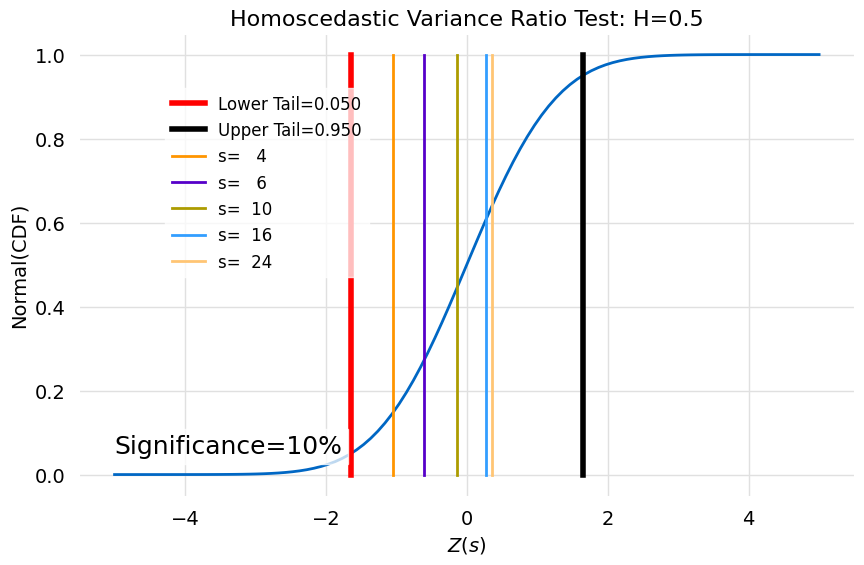

In [106]:
homo_test_stat_plot(result, H)

In [107]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.047 │    0.852 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.602 │    0.727 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.145 │    0.557 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.274 │    0.392 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0.363 │    0.358 │ Pas

In [108]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -1.0465470806178692,
                "test_id": "a9eaa8d6-3378-4356-86da-d7993f67b1a0"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.8523457400434393,
                "test_id": "a9eaa8d6-3378-4356-86da-d7993f67b1a0"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "a9eaa8d6-3378-4356-86da-d7993f67b1a0"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "a9eaa8d6-3378-4356-86da-d7993f67b1a0"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)$",
               

In [109]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.047 │    0.148 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.602 │    0.273 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.145 │    0.443 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.274 │    0.608 │ Passed   │
├─────┼────────┼──────────┼───────

In [110]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -1.0465470806178692,
                "test_id": "f385feda-6865-4c15-a3f1-4379dbaf6d95"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.14765425995656073,
                "test_id": "f385feda-6865-4c15-a3f1-4379dbaf6d95"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "f385feda-6865-4c15-a3f1-4379dbaf6d95"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "f385feda-6865-4c15-a3f1-4379dbaf6d95"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.281551565

### $H = 0.35$

Here a lower tail test is performed for fractional brownian with $H<\frac{1}{2}$. The test is successful if the result is **Failed**.

In [111]:
H=0.35
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.535 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.37  │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.153 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.699 │    0.003 │ Failed   │
├─────┼────────┼──────────┼───────

In [112]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.534605974496364,
                "test_id": "3dfd027b-0e27-4a6d-b37d-361426c01a66"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.00020419181907706783,
                "test_id": "3dfd027b-0e27-4a6d-b37d-361426c01a66"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "3dfd027b-0e27-4a6d-b37d-361426c01a66"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "3dfd027b-0e27-4a6d-b37d-361426c01a66"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.2815515

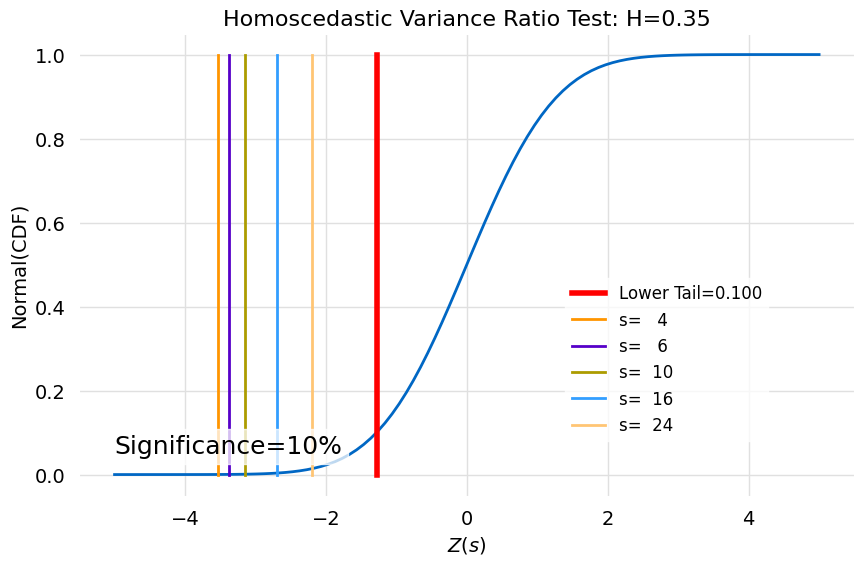

In [113]:
homo_test_stat_plot(result, H)

In [114]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.535 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.37  │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.153 │    0.999 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.699 │    0.997 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2.199 │    0.986 │ Pas

In [115]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.534605974496364,
                "test_id": "c67afde4-ddf3-4bac-9daf-b6d89aa0b3b0"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.999795808180923,
                "test_id": "c67afde4-ddf3-4bac-9daf-b6d89aa0b3b0"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "c67afde4-ddf3-4bac-9daf-b6d89aa0b3b0"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "c67afde4-ddf3-4bac-9daf-b6d89aa0b3b0"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)$",
                "

In [116]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -3.535 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -3.37  │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.153 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -2.699 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2

In [117]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": -3.534605974496364,
                "test_id": "66adf20a-2e96-48be-b354-d8ca493ff48d"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.0004083836381540973,
                "test_id": "66adf20a-2e96-48be-b354-d8ca493ff48d"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "66adf20a-2e96-48be-b354-d8ca493ff48d"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "66adf20a-2e96-48be-b354-d8ca493ff48d"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536269514729,
   

### $H = 0.6$

Here an upper tailed test for fractional brownian motion with $H > \frac{1}{2}$. The test is successful if the result is **Failed**.

In [118]:
H=0.6
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.791 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.573 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.85  │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.496 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  4.569 │        0 │ Fai

In [119]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.7909606716438513,
                "test_id": "b37ff268-d3e2-4a57-8854-53786e6dd1c6"
            },
            "pval": {
                "label": "$p-value$",
                "value": 7.503285878085464e-05,
                "test_id": "b37ff268-d3e2-4a57-8854-53786e6dd1c6"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "b37ff268-d3e2-4a57-8854-53786e6dd1c6"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "b37ff268-d3e2-4a57-8854-53786e6dd1c6"
            },
            "lower": null,
            "upper": {
                "label": "$Z_U(s)$",
             

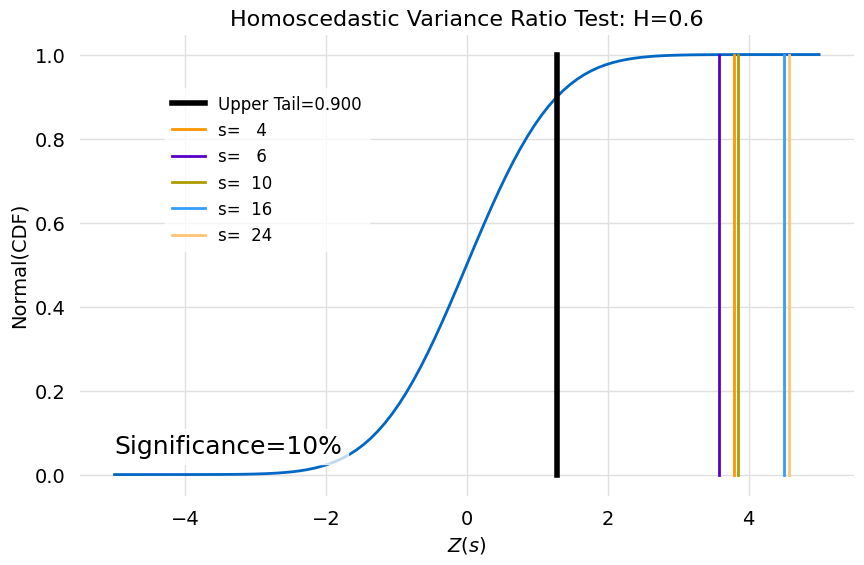

In [120]:
homo_test_stat_plot(result, H)

In [121]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.791 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.573 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.85  │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.496 │        1 │ Passed   │
├─────┼────────┼──────────┼───────

In [122]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.7909606716438513,
                "test_id": "c6cbde8f-a136-4c38-916e-942cb3dab889"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.9999249671412191,
                "test_id": "c6cbde8f-a136-4c38-916e-942cb3dab889"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "c6cbde8f-a136-4c38-916e-942cb3dab889"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "c6cbde8f-a136-4c38-916e-942cb3dab889"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.28155156554

In [123]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  3.791 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  3.573 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.85  │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.496 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  4

In [124]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$Z(s)$",
                "value": 3.7909606716438513,
                "test_id": "0cd2b6c2-227e-453d-9b88-748bca6a98fa"
            },
            "pval": {
                "label": "$p-value$",
                "value": 0.00015006571756170928,
                "test_id": "0cd2b6c2-227e-453d-9b88-748bca6a98fa"
            },
            "params": [
                {
                    "label": "$s$",
                    "value": 4,
                    "test_id": "0cd2b6c2-227e-453d-9b88-748bca6a98fa"
                }
            ],
            "sig": {
                "label": "10%",
                "value": 0.1,
                "test_id": "0cd2b6c2-227e-453d-9b88-748bca6a98fa"
            },
            "lower": {
                "label": "$Z_L(s)$",
                "value": -1.6448536269514729,
  